# Treatment-Specific Biomarker Analysis

## Major scientific question

Do baseline biomarkers have different associations with objective response in
the TRIDENT + SOC and SOC treatment arms?

## Pharmaceutical objective

Determine whether any baseline biomarker may help identify patients who are
more likely to benefit specifically from TRIDENT treatment, rather than merely
being associated with outcome regardless of treatment.

## Prognostic versus predictive interpretation

A prognostic biomarker is associated with clinical outcome regardless of
treatment. A predictive biomarker identifies patients who may experience a
different treatment effect based on their biomarker value.

This analysis will examine whether biomarker–response associations differ
between the TRIDENT + SOC and SOC treatment arms. Evidence of an association
within only one arm is not, by itself, sufficient to establish predictive
value. The difference between treatment-specific associations must be
evaluated directly through a biomarker-by-treatment interaction.

## Objective response by treatment arm

**Objective:** Compare the observed objective response rate between the
TRIDENT + SOC and SOC treatment arms before evaluating biomarker-specific
patterns.

**Clinical hypothesis:** Patients receiving TRIDENT + SOC may have a higher
objective response rate than patients receiving SOC alone.

This initial comparison describes the observed treatment-arm response rates.
It does not yet determine whether any biomarker predicts differential
treatment benefit.

In [1]:
 # Import tools for file paths and data handling
from pathlib import Path
import pandas as pd

# Import tools for numerical calculations and statistical analysis
import numpy as np
from scipy import stats

# Import tools for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the project root whether the notebook is launched
# from the repository root or from the notebooks folder
CURRENT_DIR = Path.cwd()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

# Define output directories
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

# Create output directories if needed
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Define paths to the raw clinical and biomarker datasets
clinical_path = PROJECT_ROOT / "data" / "raw" / "clinical.csv"
biomarker_path = PROJECT_ROOT / "data" / "raw" / "biomarkers.csv"

# Display the resolved paths for verification
print("Project root:", PROJECT_ROOT)
print("Clinical data path:", clinical_path)
print("Biomarker data path:", biomarker_path)

Project root: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis
Clinical data path: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/data/raw/clinical.csv
Biomarker data path: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/data/raw/biomarkers.csv


In [2]:
# Load the raw clinical and biomarker datasets
clinical_df = pd.read_csv(clinical_path)
biomarker_df = pd.read_csv(biomarker_path)

# Confirm that both datasets loaded successfully
print("Clinical data shape:", clinical_df.shape)
print("Biomarker data shape:", biomarker_df.shape)

Clinical data shape: (251, 15)
Biomarker data shape: (248, 9)


## Data preparation

The previously established clinical and baseline-biomarker cleaning rules
are applied consistently with Notebook 04. Clinical and baseline biomarker
records are deduplicated by patient ID, and Best Overall Response is
categorized as responder (CR/PR) or non-responder (SD/PD).

Patients without an evaluable response are excluded. Clinical and biomarker
records are then combined using a validated one-to-one inner merge.

In [3]:
# Apply the previously established patient-level deduplication
clinical_clean = (
    clinical_df
    .drop_duplicates(subset="patient_id", keep="first")
    .copy()
)

# Harmonize inconsistent treatment-arm capitalization
clinical_clean["treatment_arm"] = (
    clinical_clean["treatment_arm"]
    .replace({"Trident + SOC": "TRIDENT + SOC"})
)

# Verify the standardized treatment-arm categories and patient counts
print(clinical_clean["treatment_arm"].value_counts())

# Retain baseline biomarker records only and ensure one record per patient
baseline_biomarkers = (
    biomarker_df
    .loc[biomarker_df["sample_timepoint"] == "Baseline"]
    .drop_duplicates(subset="patient_id", keep="first")
    .copy()
)

# Map the four BOR categories into a binary objective-response endpoint
response_map = {
    "CR": "Responder",
    "PR": "Responder",
    "SD": "Non-responder",
    "PD": "Non-responder",
}

clinical_clean["response_group"] = (
    clinical_clean["best_overall_response"].map(response_map)
)

# Retain only patients with an evaluable objective-response outcome
response_evaluable = clinical_clean.loc[
    clinical_clean["response_group"].notna()
].copy()

# Combine clinical outcomes with baseline biomarker measurements
response_analysis = response_evaluable.merge(
    baseline_biomarkers,
    on="patient_id",
    how="inner",
    validate="one_to_one",
    suffixes=("_clinical", "_biomarker"),
)

# Confirm the number of patients retained at each stage
print("Unique clinical patients:", clinical_clean["patient_id"].nunique())
print(
    "Response-evaluable clinical patients:",
    response_evaluable["patient_id"].nunique()
)
print(
    "Unique baseline biomarker patients:",
    baseline_biomarkers["patient_id"].nunique()
)
print("Patients in merged analysis:", response_analysis["patient_id"].nunique())

treatment_arm
TRIDENT + SOC    125
SOC              125
Name: count, dtype: int64
Unique clinical patients: 250
Response-evaluable clinical patients: 249
Unique baseline biomarker patients: 247
Patients in merged analysis: 246


## Objective response by treatment arm

**Objective:** Compare the observed Objective Response Rate (ORR) between
the TRIDENT + SOC and SOC treatment arms in the merged analysis population.

**Clinical hypothesis:** TRIDENT + SOC may produce a higher objective
response rate than SOC alone.

This comparison describes the overall treatment–response association. It
does not yet determine whether a baseline biomarker predicts differential
benefit from TRIDENT.

In [4]:
# Count responders and non-responders within each treatment arm
response_by_arm = pd.crosstab(
    response_analysis["treatment_arm"],
    response_analysis["response_group"]
)

# Arrange the response categories in a clinically intuitive order
response_by_arm = response_by_arm[
    ["Responder", "Non-responder"]
]

# Calculate the number of response-evaluable patients in each arm
response_by_arm["Total"] = response_by_arm.sum(axis=1)

# Calculate ORR as the proportion achieving CR or PR within each arm
response_by_arm["ORR_percent"] = (
    response_by_arm["Responder"]
    / response_by_arm["Total"]
    * 100
)

# Display the treatment-arm response summary
response_by_arm

response_group,Responder,Non-responder,Total,ORR_percent
treatment_arm,,,,
SOC,24,98,122,19.672131
TRIDENT + SOC,43,81,124,34.677419


In [5]:
# Extract the ORR for each treatment arm
orr_trident = response_by_arm.loc[
    "TRIDENT + SOC", "ORR_percent"
]

orr_soc = response_by_arm.loc[
    "SOC", "ORR_percent"
]

# Calculate the absolute ORR difference in percentage points
orr_difference = orr_trident - orr_soc

print(f"TRIDENT + SOC ORR: {orr_trident:.1f}%")
print(f"SOC ORR: {orr_soc:.1f}%")
print(f"Absolute ORR difference: {orr_difference:.1f} percentage points")

TRIDENT + SOC ORR: 34.7%
SOC ORR: 19.7%
Absolute ORR difference: 15.0 percentage points


### Uncertainty around the absolute ORR difference

A bootstrap procedure will estimate the sampling uncertainty around the
absolute difference in ORR between TRIDENT + SOC and SOC. Patients will be
resampled with replacement within their original treatment arms, preserving
the observed arm sizes.

The resulting confidence interval describes uncertainty around the observed
treatment-arm difference. It does not correct for missing data, measurement
error, protocol deviations, or lack of representativeness.

In [6]:
# Convert the response outcome to a numeric indicator
# Responder = 1 and non-responder = 0
response_analysis["response_binary"] = (
    response_analysis["response_group"]
    .map({
        "Responder": 1,
        "Non-responder": 0,
    })
)

# Extract the binary response outcomes from each treatment arm
trident_response = response_analysis.loc[
    response_analysis["treatment_arm"] == "TRIDENT + SOC",
    "response_binary"
].to_numpy()

soc_response = response_analysis.loc[
    response_analysis["treatment_arm"] == "SOC",
    "response_binary"
].to_numpy()

# Create a reproducible random-number generator
rng = np.random.default_rng(seed=42)

# Store the bootstrapped absolute ORR differences
bootstrap_orr_differences = []

# Resample patients within each treatment arm 5,000 times
for _ in range(5000):

    # Resample each arm while preserving its original sample size
    trident_sample = rng.choice(
        trident_response,
        size=len(trident_response),
        replace=True
    )

    soc_sample = rng.choice(
        soc_response,
        size=len(soc_response),
        replace=True
    )

    # Calculate the ORR difference and convert it to percentage points
    bootstrap_difference = (
        trident_sample.mean() - soc_sample.mean()
    ) * 100

    bootstrap_orr_differences.append(bootstrap_difference)

# Use the percentile method to estimate the 95% confidence interval
orr_ci_lower, orr_ci_upper = np.percentile(
    bootstrap_orr_differences,
    [2.5, 97.5]
)

print(f"Absolute ORR difference: {orr_difference:.1f} percentage points")
print(
    f"Bootstrap 95% CI: "
    f"{orr_ci_lower:.1f} to {orr_ci_upper:.1f} percentage points"
)

Absolute ORR difference: 15.0 percentage points
Bootstrap 95% CI: 4.3 to 25.6 percentage points


### Statistical evidence for the treatment–response association

A chi-square test of independence will evaluate whether objective-response
status is associated with treatment arm.

The test evaluates statistical evidence against independence. It does not
measure the magnitude of the treatment effect; therefore, it is interpreted
after the absolute ORR difference and its confidence interval.

In [7]:
# Construct the 2 × 2 treatment-arm response table
contingency_table = pd.crosstab(
    response_analysis["treatment_arm"],
    response_analysis["response_group"]
).reindex(
    index=["SOC", "TRIDENT + SOC"],
    columns=["Responder", "Non-responder"]
)

# Perform the chi-square test of independence
chi2_statistic, chi2_p_value, degrees_freedom, expected_counts = (
    stats.chi2_contingency(contingency_table)
)

# Display the observed patient counts
print("Observed counts:")
print(contingency_table)

# Display the statistical-test results
print(f"\nChi-square statistic: {chi2_statistic:.3f}")
print(f"Degrees of freedom: {degrees_freedom}")
print(f"Raw p-value: {chi2_p_value:.4f}")

# Display expected counts to check the chi-square assumption
expected_counts_df = pd.DataFrame(
    expected_counts,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("\nExpected counts under independence:")
print(expected_counts_df.round(2))

Observed counts:
response_group  Responder  Non-responder
treatment_arm                           
SOC                    24             98
TRIDENT + SOC          43             81

Chi-square statistic: 6.250
Degrees of freedom: 1
Raw p-value: 0.0124

Expected counts under independence:
response_group  Responder  Non-responder
treatment_arm                           
SOC                 33.23          88.77
TRIDENT + SOC       33.77          90.23


### Treatment-arm response interpretation

In the merged analysis population, the observed ORR was 34.7% with
TRIDENT + SOC and 19.7% with SOC. This corresponded to an absolute
difference of 15.0 percentage points (bootstrap 95% CI: 4.3–25.6).

The chi-square test provided evidence of an association between treatment
arm and objective response (χ² = 6.25, p = 0.012). All expected cell counts
exceeded five, supporting use of the chi-square approximation.

These results describe the overall treatment–response association before
considering baseline biomarkers. They do not establish whether any biomarker
predicts differential benefit from TRIDENT.

## PD-L1 TPS as a potential predictive biomarker

**Objective:** Evaluate whether the association between baseline PD-L1 TPS
and objective response differs between the TRIDENT + SOC and SOC treatment
arms.

**Biological hypothesis:** If TRIDENT treatment modifies antitumor immune
activity, baseline PD-L1 expression may have a different association with
objective response in the TRIDENT + SOC arm than in the SOC arm.

PD-L1 TPS will initially be retained as a continuous variable to preserve
information and avoid introducing an arbitrary data-derived cutoff. The
patient-level distributions will be examined before fitting a formal
treatment-by-biomarker interaction model.

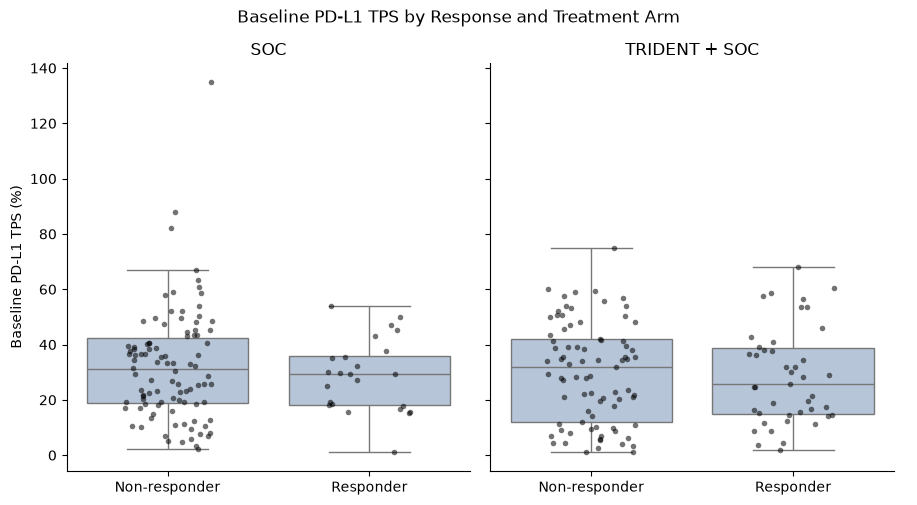

In [8]:
# Set clinically intuitive category orders
treatment_order = ["SOC", "TRIDENT + SOC"]
response_order = ["Non-responder", "Responder"]

# Create separate panels for the two treatment arms
g = sns.catplot(
    data=response_analysis,
    x="response_group",
    y="pdl1_tps_percent",
    col="treatment_arm",
    order=response_order,
    col_order=treatment_order,
    kind="box",
    showfliers=False,
    color="lightsteelblue",
    height=5,
    aspect=0.9
)

# Add individual patient measurements to each treatment-arm panel
for ax, treatment_arm in zip(g.axes.flat, treatment_order):
    arm_data = response_analysis.loc[
        response_analysis["treatment_arm"] == treatment_arm
    ]

    sns.stripplot(
        data=arm_data,
        x="response_group",
        y="pdl1_tps_percent",
        order=response_order,
        color="black",
        alpha=0.55,
        jitter=0.22,
        size=4,
        ax=ax
    )

    # Add clear panel and axis labels
    ax.set_title(treatment_arm)
    ax.set_xlabel("")
    ax.set_ylabel("Baseline PD-L1 TPS (%)")

# Add an overall figure title
g.figure.suptitle(
    "Baseline PD-L1 TPS by Response and Treatment Arm",
    y=1.04
)

plt.show()

### Descriptive statistics for PD-L1 by treatment and response

**Objective:** Quantify the center and spread of baseline PD-L1 TPS within
each treatment-arm and response subgroup before fitting an interaction model.

The median and interquartile range will describe the typical values and
variability. These descriptive comparisons do not, by themselves, establish
a treatment-specific predictive effect.

In [9]:
# Calculate PD-L1 descriptive statistics within each treatment-response group
pdl1_group_summary = (
    response_analysis
    .groupby(
        ["treatment_arm", "response_group"]
    )["pdl1_tps_percent"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
)

# Calculate the interquartile range
pdl1_group_summary["iqr"] = (
    pdl1_group_summary["q3"]
    - pdl1_group_summary["q1"]
)

# Arrange the rows in a clinically intuitive order
pdl1_group_summary = pdl1_group_summary.reindex(
    pd.MultiIndex.from_product(
        [
            ["SOC", "TRIDENT + SOC"],
            ["Non-responder", "Responder"],
        ],
        names=["treatment_arm", "response_group"]
    )
)

# Display rounded values for interpretation
pdl1_group_summary.round(2)

n   mean  median    std     q1     q3    iqr
treatment_arm response_group                                               
SOC           Non-responder   98  32.17   31.05  20.29  18.73  42.38  23.65
              Responder       24  28.68   29.35  13.12  18.00  35.95  17.95
TRIDENT + SOC Non-responder   81  29.91   31.90  18.04  11.90  41.90  30.00
              Responder       43  28.69   25.80  17.39  14.95  38.65  23.70

### Logistic regression with a PD-L1-by-treatment interaction

**Objective:** Formally evaluate whether the association between baseline
PD-L1 TPS and objective response differs between treatment arms.

A logistic regression model will include treatment arm, standardized PD-L1
TPS, and their interaction. The interaction term is the primary term for
evaluating potential predictive value.

PD-L1 will be standardized so that its coefficient represents a
one-standard-deviation increase. Standardization changes the scale but does
not change the underlying patient ordering or statistical evidence.

In [10]:
# Import formula-based statistical modeling
import statsmodels.formula.api as smf

# Retain complete observations required for the PD-L1 interaction model
pdl1_model_data = response_analysis[
    [
        "patient_id",
        "treatment_arm",
        "response_binary",
        "pdl1_tps_percent",
    ]
].dropna().copy()

# Encode treatment so SOC is the reference arm
# SOC = 0 and TRIDENT + SOC = 1
pdl1_model_data["treatment_binary"] = (
    pdl1_model_data["treatment_arm"]
    .map({
        "SOC": 0,
        "TRIDENT + SOC": 1,
    })
)

# Standardize PD-L1 using the analysis-population mean and standard deviation
pdl1_mean = pdl1_model_data["pdl1_tps_percent"].mean()
pdl1_std = pdl1_model_data["pdl1_tps_percent"].std()

pdl1_model_data["pdl1_z"] = (
    pdl1_model_data["pdl1_tps_percent"] - pdl1_mean
) / pdl1_std

# Verify the model population and standardized biomarker
print("Model sample size:", len(pdl1_model_data))
print(f"Original PD-L1 mean: {pdl1_mean:.2f}%")
print(f"Original PD-L1 standard deviation: {pdl1_std:.2f}%")
print(f"Standardized PD-L1 mean: {pdl1_model_data['pdl1_z'].mean():.3f}")
print(f"Standardized PD-L1 SD: {pdl1_model_data['pdl1_z'].std():.3f}")

Model sample size: 246
Original PD-L1 mean: 30.48%
Original PD-L1 standard deviation: 18.42%
Standardized PD-L1 mean: -0.000
Standardized PD-L1 SD: 1.000


In [11]:
# Fit logistic regression with main effects and an interaction
pdl1_interaction_model = smf.logit(
    formula=(
        "response_binary ~ "
        "treatment_binary + "
        "pdl1_z + "
        "treatment_binary:pdl1_z"
    ),
    data=pdl1_model_data
).fit()

# Display the coefficient table
pdl1_interaction_model.summary2().tables[1]

Optimization terminated successfully.
         Current function value: 0.569548
         Iterations 6


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-1.408333,0.228953,-6.151181,7.690821e-10,-1.857073,-0.959593
treatment_binary,0.770457,0.297111,2.593160,9.509848e-03,0.188130,1.352785
pdl1_z,-0.197257,0.245195,-0.804490,4.211143e-01,-0.677831,0.283317
treatment_binary:pdl1_z,0.125068,0.314726,0.397388,6.910813e-01,-0.491783,0.741919


In [12]:
# Extract model coefficients and confidence limits
pdl1_coefficients = pdl1_interaction_model.params
pdl1_confidence_intervals = pdl1_interaction_model.conf_int()

# Convert log-odds coefficients into odds ratios
pdl1_odds_ratios = np.exp(pdl1_coefficients)
pdl1_or_ci_lower = np.exp(pdl1_confidence_intervals[0])
pdl1_or_ci_upper = np.exp(pdl1_confidence_intervals[1])

# Assemble an interpretable results table
pdl1_model_results = pd.DataFrame({
    "coefficient": pdl1_coefficients,
    "odds_ratio": pdl1_odds_ratios,
    "ci_lower": pdl1_or_ci_lower,
    "ci_upper": pdl1_or_ci_upper,
    "p_value": pdl1_interaction_model.pvalues,
})

# Display rounded values
pdl1_model_results.round(3)

,coefficient,odds_ratio,ci_lower,ci_upper,p_value
Intercept,-1.408,0.245,0.156,0.383,0.000
treatment_binary,0.770,2.161,1.207,3.868,0.010
pdl1_z,-0.197,0.821,0.508,1.328,0.421
treatment_binary:pdl1_z,0.125,1.133,0.612,2.100,0.691


### Interpretation of the PD-L1 interaction model

The treatment-by-PD-L1 interaction was the primary parameter for evaluating
treatment-specific predictive value. The interaction effect was small and
uncertain (interaction OR per one-standard-deviation increase in PD-L1 TPS =
1.13, 95% CI: 0.61–2.10; p = 0.691).

The point estimate suggests that the association between baseline PD-L1 TPS
and objective response was slightly less negative in the TRIDENT + SOC arm
than in the SOC arm. However, the confidence interval was wide and included
the null value of 1, providing no convincing evidence that the PD-L1–response
association differed between treatment arms.

Although TRIDENT + SOC showed higher response odds than SOC at the mean PD-L1
level, this treatment main effect does not establish PD-L1 as a predictive
biomarker. In this analysis, baseline PD-L1 TPS did not demonstrate
treatment-specific predictive value for objective response. This result does
not prove the absence of a predictive effect because the interaction estimate
was imprecise.

## Model-Based PD-L1 Response Probabilities

### Objective

Visualize the fitted treatment-by-PD-L1 interaction by estimating objective
response probabilities across the observed baseline PD-L1 TPS range for the
TRIDENT + SOC and SOC treatment arms.

### Rationale

Predicted probabilities are easier to interpret clinically than logistic-
regression coefficients and interaction odds ratios. Before generating the
curves, the observed PD-L1 range will be checked to avoid extrapolation and to
identify biologically implausible values.

In [13]:
# Identify the observed PD-L1 range in the model population
pdl1_min = pdl1_model_data["pdl1_tps_percent"].min()
pdl1_max = pdl1_model_data["pdl1_tps_percent"].max()

# Create 100 evenly spaced PD-L1 values across the observed range
pdl1_values = np.linspace(pdl1_min, pdl1_max, 100)

print(f"Observed PD-L1 range: {pdl1_min:.2f}% to {pdl1_max:.2f}%")

Observed PD-L1 range: 1.00% to 135.00%


In [14]:
# Check for PD-L1 TPS values outside the biologically valid 0%–100% range
invalid_pdl1 = pdl1_model_data.loc[
    ~pdl1_model_data["pdl1_tps_percent"].between(0, 100),
    [
        "patient_id",
        "treatment_arm",
        "response_binary",
        "pdl1_tps_percent",
    ],
].copy()

# Add readable response labels for inspection
invalid_pdl1["response_group"] = invalid_pdl1["response_binary"].map(
    {
        1: "Responder",
        0: "Non-responder",
    }
)

invalid_pdl1

,patient_id,treatment_arm,response_binary,pdl1_tps_percent,response_group
154,TRI-156,SOC,0,135.0,Non-responder


In [15]:
# Trace the implausible value back to the raw biomarker data
biomarker_df.loc[
    biomarker_df["patient_id"] == "TRI-156"
]

,patient_id,sample_timepoint,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,ifn_gamma_pg_ml,vegf_pg_ml,pdl1_tps_percent,ctdna_fraction_percent
155,TRI-156,Baseline,5.24,3.65,3.41,4.71,470.8,135.0,3.27


### PD-L1 Range Check

One patient (TRI-156) had a baseline PD-L1 TPS of 135%, which is outside
the biologically valid range of 0%–100%. Review of the raw biomarker table
confirmed a single baseline record with no alternative PD-L1 measurement.
Therefore, this value was treated as invalid and excluded from PD-L1-specific
analyses. The patient was not excluded from analyses of other biomarkers.

In [16]:
# Retain only biologically valid PD-L1 TPS measurements
pdl1_model_data = pdl1_model_data.loc[
    pdl1_model_data["pdl1_tps_percent"].between(0, 100)
].copy()

# Recalculate the mean and SD after excluding the invalid measurement
pdl1_mean = pdl1_model_data["pdl1_tps_percent"].mean()
pdl1_std = pdl1_model_data["pdl1_tps_percent"].std()

# Re-standardize PD-L1 using the QC-valid model population
pdl1_model_data["pdl1_z"] = (
    pdl1_model_data["pdl1_tps_percent"] - pdl1_mean
) / pdl1_std

print(f"QC-valid PD-L1 model sample size: {len(pdl1_model_data)}")
print(f"PD-L1 mean after QC: {pdl1_mean:.2f}%")
print(f"PD-L1 SD after QC: {pdl1_std:.2f} percentage points")
print(
    "PD-L1 range after QC:",
    f"{pdl1_model_data['pdl1_tps_percent'].min():.2f}% to",
    f"{pdl1_model_data['pdl1_tps_percent'].max():.2f}%",
)

QC-valid PD-L1 model sample size: 245
PD-L1 mean after QC: 30.05%
PD-L1 SD after QC: 17.20 percentage points
PD-L1 range after QC: 1.00% to 87.90%


In [17]:
# Refit the PD-L1 interaction model after the range-based QC exclusion
pdl1_interaction_model = smf.logit(
    formula=(
        "response_binary ~ "
        "treatment_binary + "
        "pdl1_z + "
        "treatment_binary:pdl1_z"
    ),
    data=pdl1_model_data,
).fit()

Optimization terminated successfully.
         Current function value: 0.571532
         Iterations 5


In [18]:
# Extract coefficients and 95% confidence intervals
pdl1_coefficients = pdl1_interaction_model.params
pdl1_confidence_intervals = pdl1_interaction_model.conf_int()

# Convert log-odds coefficients into odds ratios
pdl1_model_results = pd.DataFrame(
    {
        "coefficient": pdl1_coefficients,
        "odds_ratio": np.exp(pdl1_coefficients),
        "ci_lower": np.exp(pdl1_confidence_intervals[0]),
        "ci_upper": np.exp(pdl1_confidence_intervals[1]),
        "p_value": pdl1_interaction_model.pvalues,
    }
)

pdl1_model_results.round(3)

,coefficient,odds_ratio,ci_lower,ci_upper,p_value
Intercept,-1.398,0.247,0.158,0.387,0.000
treatment_binary,0.762,2.143,1.198,3.833,0.010
pdl1_z,-0.157,0.855,0.530,1.380,0.521
treatment_binary:pdl1_z,0.089,1.093,0.600,1.992,0.770


### Interpretation of the PD-L1 Interaction Model

After excluding one biologically invalid PD-L1 TPS measurement above 100%,
the PD-L1 interaction model included 245 patients. One standard deviation
represented a 17.20-percentage-point increase in PD-L1 TPS.

The treatment-by-PD-L1 interaction—the primary parameter for evaluating
treatment-specific predictive value—was small and uncertain (interaction OR
per one-SD increase = 1.09, 95% CI: 0.60–1.99; p = 0.770).

Within SOC, a one-SD increase in PD-L1 was associated with an estimated 14.5%
reduction in response odds (OR = 0.86, 95% CI: 0.53–1.38). The corresponding
estimated odds ratio in TRIDENT + SOC was approximately 0.93. However, the
wide interaction confidence interval included 1, providing no convincing
evidence that the PD-L1–response association differed between treatment arms.

Although TRIDENT + SOC showed higher response odds than SOC at the mean PD-L1
level, this treatment main effect does not establish PD-L1 as a predictive
biomarker. Baseline PD-L1 TPS did not demonstrate treatment-specific
predictive value for objective response in this analysis. The imprecise
interaction estimate does not prove the absence of a predictive effect.


### Model-Based Predicted Response Probabilities

**Objective:**  
Estimate and visualize response probabilities across the QC-valid observed
PD-L1 TPS range for the SOC and TRIDENT + SOC treatment arms.

**Biological hypothesis:**  
If baseline PD-L1 has treatment-specific predictive value, the relationship
between PD-L1 TPS and predicted response probability will differ between the
two treatment arms.

**Analysis approach:**  
The fitted logistic interaction model will be used to calculate predicted
response probabilities at 100 evenly spaced PD-L1 values from 1.0% to 87.9%.
Predictions will be generated separately for each treatment arm. Confidence
intervals will be included to show statistical uncertainty.

These model-based curves translate log-odds and interaction odds ratios into
response probabilities that are easier to interpret. They describe estimated
group-level patterns and should not be interpreted as certain predictions for
individual patients.

In [19]:
# Create 100 PD-L1 values across the QC-valid observed range
pdl1_values = np.linspace(
    pdl1_model_data["pdl1_tps_percent"].min(),
    pdl1_model_data["pdl1_tps_percent"].max(),
    100,
)

# Create one prediction row per PD-L1 value for each treatment arm
prediction_grid = pd.DataFrame(
    {
        "pdl1_tps_percent": np.tile(pdl1_values, 2),
        "treatment_binary": np.repeat([0, 1], len(pdl1_values)),
    }
)

# Standardize the prediction values using the model's QC-valid mean and SD
prediction_grid["pdl1_z"] = (
    prediction_grid["pdl1_tps_percent"] - pdl1_mean
) / pdl1_std

# Add readable treatment labels for plotting
prediction_grid["treatment_arm"] = prediction_grid[
    "treatment_binary"
].map(
    {
        0: "SOC",
        1: "TRIDENT + SOC",
    }
)

print("Prediction-grid shape:", prediction_grid.shape)
prediction_grid.groupby("treatment_arm").agg(
    n_values=("pdl1_tps_percent", "size"),
    minimum_pdl1=("pdl1_tps_percent", "min"),
    maximum_pdl1=("pdl1_tps_percent", "max"),
)

Prediction-grid shape: (200, 4)


,n_values,minimum_pdl1,maximum_pdl1
treatment_arm,,,
SOC,100,1.0,87.9
TRIDENT + SOC,100,1.0,87.9


In [20]:
# Generate model-based predictions for every row in the prediction grid
prediction_results = pdl1_interaction_model.get_prediction(
    prediction_grid
)

# Obtain predicted probabilities and their 95% confidence intervals
prediction_summary = prediction_results.summary_frame(alpha=0.05)

# Inspect the output structure before joining it to the prediction grid
print("Prediction-summary columns:")
print(prediction_summary.columns.tolist())

prediction_summary.head()

Prediction-summary columns:
['predicted', 'se', 'ci_lower', 'ci_upper']


,predicted,se,ci_lower,ci_upper
0,0.243513,0.084794,0.115507,0.442421
1,0.242043,0.082467,0.116856,0.435246
2,0.240578,0.080173,0.118200,0.428141
3,0.239120,0.077911,0.119538,0.421112
4,0.237668,0.075684,0.120868,0.414163


In [21]:
# Join predicted probabilities and confidence intervals to the prediction grid
prediction_grid = prediction_grid.reset_index(drop=True)

prediction_grid[
    ["predicted_probability", "probability_se", "ci_lower", "ci_upper"]
] = prediction_summary[
    ["predicted", "se", "ci_lower", "ci_upper"]
].reset_index(drop=True)

# Inspect predictions at the lowest and highest PD-L1 values in each arm
prediction_grid.iloc[[0, 99, 100, 199]][
    [
        "treatment_arm",
        "pdl1_tps_percent",
        "pdl1_z",
        "predicted_probability",
        "ci_lower",
        "ci_upper",
    ]
].round(3)

,treatment_arm,pdl1_tps_percent,pdl1_z,predicted_probability,ci_lower,ci_upper
0,SOC,1.0,-1.689,0.244,0.116,0.442
99,SOC,87.9,3.364,0.127,0.026,0.443
100,TRIDENT + SOC,1.0,-1.689,0.372,0.228,0.543
199,TRIDENT + SOC,87.9,3.364,0.297,0.104,0.605


In [22]:
# Objective: Create treatment-specific PD-L1 values for the rug plot

# Extract QC-valid PD-L1 values from patients in the SOC arm
soc_pdl1_values = pdl1_model_data.loc[
    pdl1_model_data["treatment_binary"] == 0,
    "pdl1_tps_percent",
].dropna().to_numpy()

# Extract QC-valid PD-L1 values from patients in the TRIDENT + SOC arm
trident_pdl1_values = pdl1_model_data.loc[
    pdl1_model_data["treatment_binary"] == 1,
    "pdl1_tps_percent",
].dropna().to_numpy()

# Verify that the two arrays cover the complete PD-L1 model population
print("SOC PD-L1 observations:", len(soc_pdl1_values))
print(
    "TRIDENT + SOC PD-L1 observations:",
    len(trident_pdl1_values),
)
print(
    "Total PD-L1 observations:",
    len(soc_pdl1_values) + len(trident_pdl1_values),
)

SOC PD-L1 observations: 121
TRIDENT + SOC PD-L1 observations: 124
Total PD-L1 observations: 245


Figure saved to:
/Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results/figures/pdl1_treatment_interaction_predicted_probabilities.png


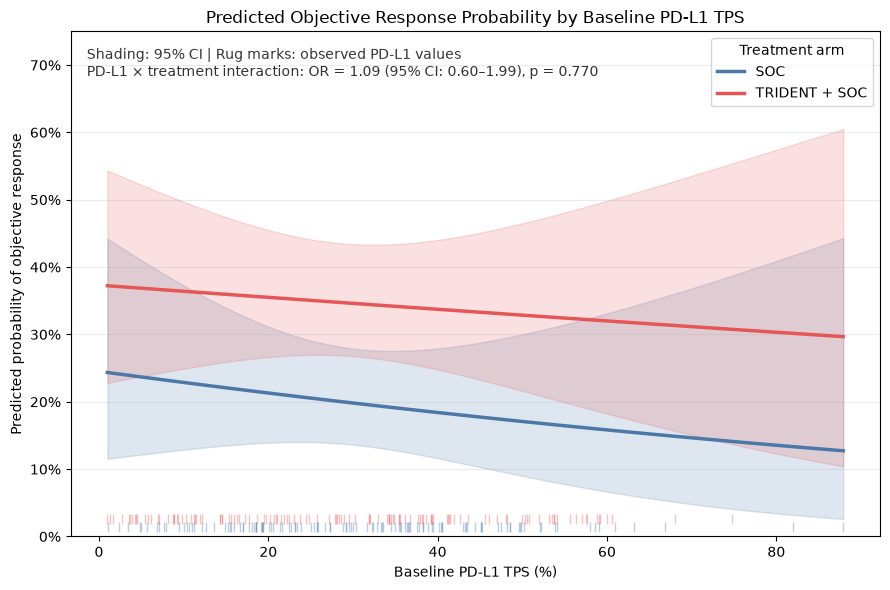

In [23]:
# Import percentage formatting for the probability axis
from matplotlib.ticker import PercentFormatter

# Assign consistent colors to the two treatment arms
arm_colors = {
    "SOC": "#4C78A8",
    "TRIDENT + SOC": "#E45756",
}

fig, ax = plt.subplots(figsize=(9, 6))

# Plot one probability curve and confidence band per treatment arm
for treatment_arm, arm_data in prediction_grid.groupby(
    "treatment_arm",
    sort=False,
):
    arm_data = arm_data.sort_values("pdl1_tps_percent")

    ax.plot(
        arm_data["pdl1_tps_percent"],
        arm_data["predicted_probability"],
        color=arm_colors[treatment_arm],
        linewidth=2.5,
        label=treatment_arm,
    )

    ax.fill_between(
        arm_data["pdl1_tps_percent"].to_numpy(),
        arm_data["ci_lower"].to_numpy(),
        arm_data["ci_upper"].to_numpy(),
        color=arm_colors[treatment_arm],
        alpha=0.18,
    )

# Label and format the plot
ax.set_xlabel("Baseline PD-L1 TPS (%)")
ax.set_ylabel("Predicted probability of objective response")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 0.75)
ax.set_title(
    "Predicted Objective Response Probability by Baseline PD-L1 TPS"
)
ax.legend(title="Treatment arm")
ax.grid(axis="y", alpha=0.25)

# Objective: Show where observed PD-L1 measurements are concentrated
# so we can evaluate how strongly different regions of the curves
# are supported by patient data.

ax.plot(
    soc_pdl1_values,
    np.full(len(soc_pdl1_values), 0.018),
    "|",
    color=arm_colors["SOC"],
    alpha=0.35,
    markersize=7,
    transform=ax.get_xaxis_transform(),
)

ax.plot(
    trident_pdl1_values,
    np.full(len(trident_pdl1_values), 0.035),
    "|",
    color=arm_colors["TRIDENT + SOC"],
    alpha=0.35,
    markersize=7,
    transform=ax.get_xaxis_transform(),
)


# Objective: Make the figure self-contained by identifying the uncertainty,
# observed-data marks, and formal biomarker-by-treatment interaction result.

plot_annotation = ax.text(
    0.02,
    0.97,
    (
        "Shading: 95% CI | Rug marks: observed PD-L1 values\n"
        "PD-L1 × treatment interaction: OR = 1.09 "
        "(95% CI: 0.60–1.99), p = 0.770"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    color="#333333",
)

plt.tight_layout()

# Objective: Save the finalized PD-L1 predicted-probability figure
# as a high-resolution portfolio-quality PNG file.

# Create an organized output directory if it does not already exist
figure_output_dir = FIGURES_DIR

# Define a descriptive output path
pdl1_probability_figure_path = (
    figure_output_dir
    / "pdl1_treatment_interaction_predicted_probabilities.png"
)

# Save before displaying the figure
fig.savefig(
    pdl1_probability_figure_path,
    dpi=300,
    bbox_inches="tight",
)

print("Figure saved to:")
print(pdl1_probability_figure_path)

plt.show()

### Interpretation

**Effect size:** Higher baseline PD-L1 TPS was associated with a modest decrease in predicted objective response probability in both treatment arms. The estimated decrease was slightly greater for SOC than for TRIDENT + SOC, while predicted response remained higher with TRIDENT + SOC across the observed PD-L1 range.

**Uncertainty:** The confidence intervals were wide, particularly at the extremes of the PD-L1 distribution where fewer patient observations were available. The biomarker-by-treatment interaction estimate was also imprecise (interaction OR per 17.20-percentage-point increase in PD-L1 = 1.09; 95% CI: 0.60–1.99).

**Statistical evidence:** The interaction p-value was 0.770, providing no convincing evidence that the association between baseline PD-L1 and objective response differed between treatment arms.

**Biological and pharmaceutical meaning:** Baseline PD-L1 TPS did not demonstrate treatment-specific predictive value for TRIDENT + SOC in this analysis. The results do not prove the absence of a true interaction because the confidence interval remains compatible with both lower and higher relative treatment effects. PD-L1 should therefore not be advanced as a treatment-selection biomarker based on this analysis alone.

In [24]:
# Separate the observed PD-L1 values by treatment arm
soc_pdl1_values = pdl1_model_data.loc[
    pdl1_model_data["treatment_arm"] == "SOC",
    "pdl1_tps_percent",
]

trident_pdl1_values = pdl1_model_data.loc[
    pdl1_model_data["treatment_arm"] == "TRIDENT + SOC",
    "pdl1_tps_percent",
]

# Check how many valid PD-L1 observations each arm contains
print("SOC observations:", len(soc_pdl1_values))
print("TRIDENT + SOC observations:", len(trident_pdl1_values))

SOC observations: 121
TRIDENT + SOC observations: 124


## Treatment-Specific Interaction Analysis Across Biomarkers

### Objective

Evaluate whether the association between each baseline biomarker and objective response differs between the SOC and TRIDENT + SOC treatment arms.

### Biological hypothesis

If a baseline biomarker is predictive of TRIDENT treatment benefit, its association with objective response will differ between treatment arms. This treatment-specific difference will be evaluated using a biomarker-by-treatment interaction term.

Before modeling, each biomarker will undergo assay-appropriate quality control. Validity rules will reflect its biological measurement and units rather than applying PD-L1 TPS limits to all biomarkers.

In [25]:
# Objective: Summarize the distributions and potential QC issues
# for the six remaining baseline biomarkers before modeling.

# List the biomarkers that still require interaction analysis
interaction_biomarkers = [
    "il6_pg_ml",
    "crp_mg_l",
    "tnf_alpha_pg_ml",
    "ifn_gamma_pg_ml",
    "vegf_pg_ml",
    "ctdna_fraction_percent",
]

# Collect one QC summary row for each biomarker
biomarker_qc_rows = []

for biomarker in interaction_biomarkers:
    # Convert unexpected nonnumeric entries to missing values
    biomarker_values = pd.to_numeric(
        response_analysis[biomarker],
        errors="coerce",
    )

    # Record missingness, unusual values, and distribution summaries
    biomarker_qc_rows.append(
        {
            "biomarker": biomarker,
            "non_missing_n": biomarker_values.notna().sum(),
            "missing_n": biomarker_values.isna().sum(),
            "zero_n": (biomarker_values == 0).sum(),
            "negative_n": (biomarker_values < 0).sum(),
            "infinite_n": np.isinf(biomarker_values).sum(),
            "minimum": biomarker_values.min(),
            "q1": biomarker_values.quantile(0.25),
            "median": biomarker_values.median(),
            "q3": biomarker_values.quantile(0.75),
            "maximum": biomarker_values.max(),
        }
    )

# Convert the collected summaries into an inspection table
biomarker_qc_summary = pd.DataFrame(biomarker_qc_rows)

biomarker_qc_summary

,biomarker,non_missing_n,missing_n,zero_n,negative_n,infinite_n,minimum,q1,median,q3,maximum
0,il6_pg_ml,245,1,0,0,0,2.36,5.9600,8.270,12.4700,43.77
1,crp_mg_l,245,1,0,0,0,0.10,5.1900,7.910,11.7800,34.39
2,tnf_alpha_pg_ml,246,0,0,1,0,-4.80,4.2000,5.745,7.9475,21.26
3,ifn_gamma_pg_ml,246,0,0,0,0,1.10,3.5475,4.590,6.3600,18.83
4,vegf_pg_ml,246,0,0,0,0,9.00,191.1000,239.250,309.2750,478.70
5,ctdna_fraction_percent,246,0,0,0,0,0.27,2.0600,3.360,6.2600,95.00


In [26]:
# Objective: Identify the biologically invalid negative TNF-alpha record
# and inspect the upper tail of the ctDNA fraction distribution.

# Select records with an invalid negative TNF-alpha concentration
invalid_tnf_alpha = response_analysis.loc[
    response_analysis["tnf_alpha_pg_ml"] < 0,
    [
        "patient_id",
        "treatment_arm",
        "response_group",
        "tnf_alpha_pg_ml",
    ],
]

# Inspect the patients with the highest baseline ctDNA fractions
highest_ctdna_records = (
    response_analysis.loc[
        :,
        [
            "patient_id",
            "treatment_arm",
            "response_group",
            "ctdna_fraction_percent",
        ],
    ]
    .sort_values(
        "ctdna_fraction_percent",
        ascending=False,
    )
    .head(10)
)

print("Invalid negative TNF-alpha record:")
display(invalid_tnf_alpha)

print("\nTen highest ctDNA fraction values:")
display(highest_ctdna_records)

Invalid negative TNF-alpha record:


,patient_id,treatment_arm,response_group,tnf_alpha_pg_ml
118,TRI-120,SOC,Non-responder,-4.8



Ten highest ctDNA fraction values:


,patient_id,treatment_arm,response_group,ctdna_fraction_percent
17,TRI-018,SOC,Non-responder,95.00
231,TRI-233,TRIDENT + SOC,Non-responder,28.87
56,TRI-057,TRIDENT + SOC,Responder,26.73
196,TRI-198,SOC,Non-responder,26.28
156,TRI-158,SOC,Non-responder,23.53
67,TRI-068,SOC,Non-responder,21.55
48,TRI-049,TRIDENT + SOC,Responder,17.25
64,TRI-065,TRIDENT + SOC,Non-responder,16.73
35,TRI-036,SOC,Non-responder,15.93
89,TRI-090,SOC,Non-responder,14.20


In [27]:
# Objective: Trace the flagged TNF-alpha and ctDNA measurements
# to the original biomarker data and check for alternative records.

flagged_biomarker_records = (
    biomarker_df.loc[
        biomarker_df["patient_id"].isin(["TRI-120", "TRI-018"]),
        [
            "patient_id",
            "sample_timepoint",
            "tnf_alpha_pg_ml",
            "ctdna_fraction_percent",
        ],
    ]
    .sort_values(
        ["patient_id", "sample_timepoint"],
    )
)

flagged_biomarker_records

,patient_id,sample_timepoint,tnf_alpha_pg_ml,ctdna_fraction_percent
17,TRI-018,Baseline,4.18,95.00
119,TRI-120,Baseline,-4.80,12.62


### Biomarker-specific QC decisions

- **TNF-α:** TRI-120 had a baseline TNF-α concentration of −4.80 pg/mL. Because a protein concentration cannot be negative and no alternative baseline measurement was available, this value was treated as missing for TNF-α-specific analyses. TRI-120 remained eligible for analyses of other valid biomarkers.
- **ctDNA fraction:** TRI-018 had a baseline ctDNA fraction of 95.0%. The value was confirmed in the original biomarker data and falls within the biologically possible range of 0%–100%. It was retained in the primary ctDNA model but flagged for a sensitivity analysis because it was substantially higher than the next-highest observed value.
- **IL-6 and CRP:** Each had one missing baseline value. Missing observations will be excluded only from the corresponding biomarker-specific model.
- **IFN-γ and VEGF:** No biologically invalid values were identified in the initial range checks.
- QC exclusions are biomarker-specific; patients are not removed from analyses of their other valid biomarkers.

In [28]:
# Objective: Create a working dataset for interaction modeling while
# preserving the original response-analysis dataset unchanged.

# Copy the complete merged analysis dataset
interaction_analysis_data = response_analysis.copy()

# Treat the biologically invalid negative TNF-alpha value as missing
# only for TNF-alpha-specific analysis
interaction_analysis_data.loc[
    interaction_analysis_data["tnf_alpha_pg_ml"] < 0,
    "tnf_alpha_pg_ml",
] = np.nan

# Store the patient identifier for the planned ctDNA sensitivity analysis
ctdna_extreme_patient_id = "TRI-018"

# Confirm the biomarker-specific missing-value counts after TNF-alpha QC
interaction_analysis_data[
    interaction_biomarkers
].isna().sum()

il6_pg_ml                 1
crp_mg_l                  1
tnf_alpha_pg_ml           1
ifn_gamma_pg_ml           0
vegf_pg_ml                0
ctdna_fraction_percent    0
dtype: int64

In [29]:
# Objective: Compare raw and log-transformed biomarker skewness
# before choosing the scale for the interaction models.

biomarker_distribution_rows = []

for biomarker in interaction_biomarkers:
    # Use only QC-valid, nonmissing values for this biomarker
    valid_values = (
        interaction_analysis_data[biomarker]
        .dropna()
        .astype(float)
    )

    # All retained values must be positive before applying the natural log
    log_values = np.log(valid_values)

    biomarker_distribution_rows.append(
        {
            "biomarker": biomarker,
            "n": len(valid_values),
            "raw_skewness": stats.skew(
                valid_values,
                bias=False,
            ),
            "log_skewness": stats.skew(
                log_values,
                bias=False,
            ),
        }
    )

# Create a compact comparison table
biomarker_distribution_summary = pd.DataFrame(
    biomarker_distribution_rows
)

biomarker_distribution_summary.round(3)

,biomarker,n,raw_skewness,log_skewness
0,il6_pg_ml,245,1.781,0.216
1,crp_mg_l,245,1.540,-1.807
2,tnf_alpha_pg_ml,245,1.357,0.091
3,ifn_gamma_pg_ml,246,1.710,0.174
4,vegf_pg_ml,246,0.165,-2.656
5,ctdna_fraction_percent,246,8.283,-0.031


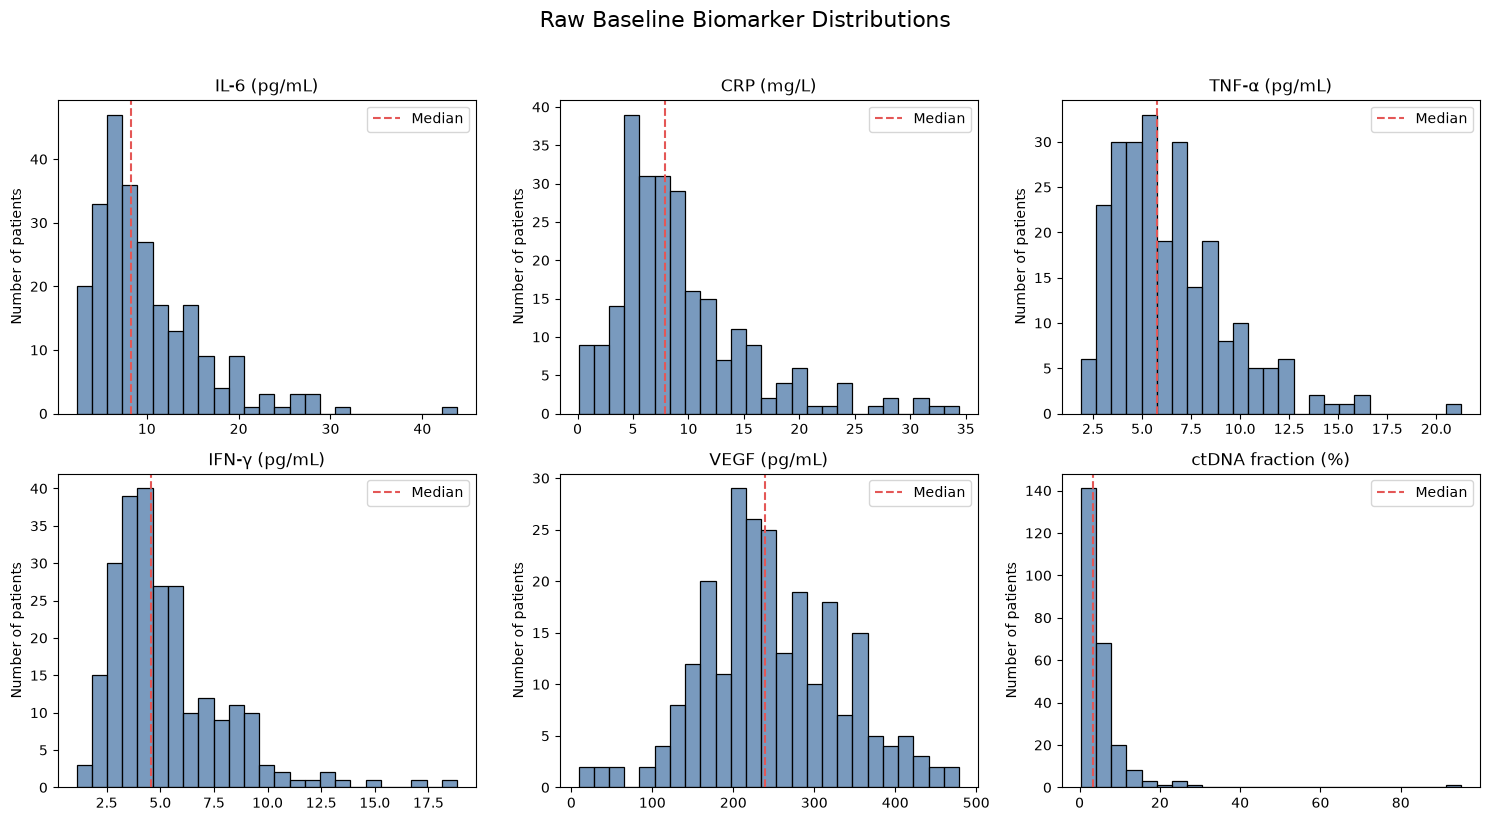

In [30]:
# Objective: Visually inspect the raw distributions of the six biomarkers
# before selecting biomarker-specific transformations.

# Create readable biomarker names for the diagnostic plots
biomarker_display_names = {
    "il6_pg_ml": "IL-6 (pg/mL)",
    "crp_mg_l": "CRP (mg/L)",
    "tnf_alpha_pg_ml": "TNF-α (pg/mL)",
    "ifn_gamma_pg_ml": "IFN-γ (pg/mL)",
    "vegf_pg_ml": "VEGF (pg/mL)",
    "ctdna_fraction_percent": "ctDNA fraction (%)",
}

# Create a two-row, three-column diagnostic figure
distribution_fig, distribution_axes = plt.subplots(
    2,
    3,
    figsize=(15, 8),
)

# Flatten the axes so they can be paired with the biomarker list
distribution_axes_flat = distribution_axes.flatten()

for biomarker, axis in zip(
    interaction_biomarkers,
    distribution_axes_flat,
):
    # Select QC-valid values for the current biomarker
    plot_values = interaction_analysis_data[biomarker].dropna()

    # Plot the raw biomarker distribution
    sns.histplot(
        plot_values,
        bins=25,
        color="#4C78A8",
        alpha=0.75,
        ax=axis,
    )

    # Mark the observed median
    axis.axvline(
        plot_values.median(),
        color="#E45756",
        linestyle="--",
        linewidth=1.5,
        label="Median",
    )

    axis.set_title(biomarker_display_names[biomarker])
    axis.set_xlabel("")
    axis.set_ylabel("Number of patients")
    axis.legend()

distribution_fig.suptitle(
    "Raw Baseline Biomarker Distributions",
    fontsize=16,
    y=1.02,
)

distribution_fig.tight_layout()
plt.show()

In [31]:
# Objective: Compare raw, square-root, and log transformations of CRP
# to identify a scale that reduces extreme right skew without overcorrecting.

# Select QC-valid CRP measurements
crp_valid_values = (
    interaction_analysis_data["crp_mg_l"]
    .dropna()
    .astype(float)
)

# Apply the less-aggressive square-root transformation
crp_sqrt_values = np.sqrt(crp_valid_values)

# Apply the natural-log transformation for comparison
crp_log_values = np.log(crp_valid_values)

# Compare the skewness produced by each scale
crp_transformation_comparison = pd.DataFrame(
    {
        "scale": [
            "Raw CRP",
            "Square-root CRP",
            "Log CRP",
        ],
        "skewness": [
            stats.skew(crp_valid_values, bias=False),
            stats.skew(crp_sqrt_values, bias=False),
            stats.skew(crp_log_values, bias=False),
        ],
    }
)

crp_transformation_comparison.round(3)

,scale,skewness
0,Raw CRP,1.540
1,Square-root CRP,0.448
2,Log CRP,-1.807


### Biomarker transformation plan

Biomarker transformations were selected before interaction modeling based on measurement validity, distribution shape, and biological interpretability—not on statistical significance.

- IL-6, TNF-α, IFN-γ, and ctDNA fraction were natural-log transformed because their raw distributions were strongly right-skewed.
- CRP was square-root transformed because this reduced right skew without the strong overcorrection observed with the natural log.
- VEGF was retained on its raw scale because its untransformed distribution was approximately symmetric.
- Each model-scale biomarker will subsequently be standardized so its odds ratio represents a one-standard-deviation increase on the selected scale.

In [32]:
# Objective: Store the prespecified transformation and display-name
# decisions for each biomarker before interaction modeling.

biomarker_model_specs = {
    "il6_pg_ml": {
        "display_name": "IL-6",
        "transformation": "log",
    },
    "crp_mg_l": {
        "display_name": "CRP",
        "transformation": "sqrt",
    },
    "tnf_alpha_pg_ml": {
        "display_name": "TNF-α",
        "transformation": "log",
    },
    "ifn_gamma_pg_ml": {
        "display_name": "IFN-γ",
        "transformation": "log",
    },
    "vegf_pg_ml": {
        "display_name": "VEGF",
        "transformation": "raw",
    },
    "ctdna_fraction_percent": {
        "display_name": "ctDNA fraction",
        "transformation": "log",
    },
}

biomarker_model_specs

{'il6_pg_ml': {'display_name': 'IL-6', 'transformation': 'log'},
 'crp_mg_l': {'display_name': 'CRP', 'transformation': 'sqrt'},
 'tnf_alpha_pg_ml': {'display_name': 'TNF-α', 'transformation': 'log'},
 'ifn_gamma_pg_ml': {'display_name': 'IFN-γ', 'transformation': 'log'},
 'vegf_pg_ml': {'display_name': 'VEGF', 'transformation': 'raw'},
 'ctdna_fraction_percent': {'display_name': 'ctDNA fraction',
  'transformation': 'log'}}

In [33]:
# Objective: Create a reusable helper function that applies the
# prespecified raw, log, or square-root biomarker transformation.

def transform_biomarker(values, transformation):
    """
    Apply a prespecified transformation to a biomarker Series.

    Parameters
    ----------
    values : pandas Series
        QC-valid biomarker measurements.

    transformation : str
        One of: "raw", "log", or "sqrt".

    Returns
    -------
    pandas Series
        Biomarker values on the selected modeling scale.
    """

    if transformation == "raw":
        # Preserve the original measurement scale
        return values.copy()

    if transformation == "log":
        # Natural log requires strictly positive values
        if (values.dropna() <= 0).any():
            raise ValueError(
                "Log transformation requires values greater than zero."
            )

        return np.log(values)

    if transformation == "sqrt":
        # Square root requires nonnegative values
        if (values.dropna() < 0).any():
            raise ValueError(
                "Square-root transformation requires nonnegative values."
            )

        return np.sqrt(values)

    # Stop the analysis if the specification contains an unknown option
    raise ValueError(
        f"Unknown transformation: {transformation}"
    )

In [34]:
# Objective: Verify that the transformation helper correctly applies
# the prespecified natural-log transformation to IL-6.

il6_transformed_preview = transform_biomarker(
    values=interaction_analysis_data["il6_pg_ml"],
    transformation=biomarker_model_specs["il6_pg_ml"]["transformation"],
)

pd.DataFrame(
    {
        "raw_il6": interaction_analysis_data["il6_pg_ml"].head(),
        "log_il6": il6_transformed_preview.head(),
    }
)

,raw_il6,log_il6
0,11.98,2.483239
1,6.78,1.913977
2,10.61,2.361797
3,13.82,2.626117
4,8.60,2.151762


In [35]:
# Objective: Create a reusable helper function that standardizes
# transformed biomarker values for comparable interaction modeling.

def standardize_biomarker(values):
    """
    Standardize biomarker values using their observed mean and SD.

    Returns
    -------
    standardized_values : pandas Series
        Values represented as z-scores.

    observed_mean : float
        Mean before standardization.

    observed_sd : float
        Sample standard deviation before standardization.
    """

    # Calculate the mean and sample SD using nonmissing values
    observed_mean = values.mean()
    observed_sd = values.std()

    # A biomarker with no variability cannot be modeled
    if observed_sd == 0 or pd.isna(observed_sd):
        raise ValueError(
            "Biomarker standard deviation must be greater than zero."
        )

    # Convert each value to its number of SDs from the mean
    standardized_values = (
        values - observed_mean
    ) / observed_sd

    return standardized_values, observed_mean, observed_sd

In [36]:
# Objective: Verify that standardized log-transformed IL-6
# has an approximate mean of 0 and standard deviation of 1.

(
    il6_z_preview,
    il6_log_mean,
    il6_log_std,
) = standardize_biomarker(
    il6_transformed_preview
)

il6_standardization_check = pd.Series(
    {
        "log_scale_mean_before_standardization": il6_log_mean,
        "log_scale_sd_before_standardization": il6_log_std,
        "z_score_mean_after_standardization": il6_z_preview.mean(),
        "z_score_sd_after_standardization": il6_z_preview.std(),
    }
)

il6_standardization_check

log_scale_mean_before_standardization    2.156415
log_scale_sd_before_standardization      0.540370
z_score_mean_after_standardization       0.000000
z_score_sd_after_standardization         1.000000
dtype: float64

In [37]:
# Objective: Create a reusable function that prepares one biomarker's
# complete-case, transformed, and standardized model dataset.

def prepare_biomarker_model_data(
    data,
    biomarker,
    transformation,
):
    """
    Prepare one biomarker for interaction modeling.

    The function:
    1. Selects the required model columns.
    2. Excludes rows missing that specific biomarker.
    3. Applies the prespecified transformation.
    4. Standardizes the transformed values.
    """

    # Keep patient information, model variables, and the selected biomarker
    model_data = data[
        [
            "patient_id",
            "treatment_arm",
            "response_group",
            "response_binary",
            "treatment_binary",
            biomarker,
        ]
    ].dropna().copy()

    # Apply the prespecified biomarker transformation
    model_data["biomarker_model_scale"] = transform_biomarker(
        values=model_data[biomarker],
        transformation=transformation,
    )

    # Standardize the transformed biomarker
    (
        model_data["biomarker_z"],
        model_scale_mean,
        model_scale_sd,
    ) = standardize_biomarker(
        model_data["biomarker_model_scale"]
    )

    return model_data, model_scale_mean, model_scale_sd

In [38]:
# Objective: Add and verify the binary treatment encoding required
# for the remaining biomarker interaction models.

interaction_analysis_data["treatment_binary"] = (
    interaction_analysis_data["treatment_arm"].map(
        {
            "SOC": 0,
            "TRIDENT + SOC": 1,
        }
    )
)

# Stop if any treatment label failed to map
if interaction_analysis_data["treatment_binary"].isna().any():
    raise ValueError(
        "One or more treatment-arm labels could not be encoded."
    )

# Verify the relationship between treatment labels and binary values
treatment_encoding_check = pd.crosstab(
    interaction_analysis_data["treatment_arm"],
    interaction_analysis_data["treatment_binary"],
)

treatment_encoding_check

treatment_binary,0,1
treatment_arm,,
SOC,122,0
TRIDENT + SOC,0,124


In [39]:
# Objective: Verify the reusable preparation function using IL-6
# before fitting any interaction models.

(
    il6_model_data_test,
    il6_model_scale_mean,
    il6_model_scale_sd,
) = prepare_biomarker_model_data(
    data=interaction_analysis_data,
    biomarker="il6_pg_ml",
    transformation="log",
)

il6_preparation_check = pd.Series(
    {
        "model_n": len(il6_model_data_test),
        "raw_missing_n": il6_model_data_test[
            "il6_pg_ml"
        ].isna().sum(),
        "biomarker_z_mean": il6_model_data_test[
            "biomarker_z"
        ].mean(),
        "biomarker_z_sd": il6_model_data_test[
            "biomarker_z"
        ].std(),
        "model_scale_mean": il6_model_scale_mean,
        "model_scale_sd": il6_model_scale_sd,
    }
)

il6_preparation_check

model_n             2.450000e+02
raw_missing_n       0.000000e+00
biomarker_z_mean   -7.250436e-18
biomarker_z_sd      1.000000e+00
model_scale_mean    2.156415e+00
model_scale_sd      5.403703e-01
dtype: float64

In [40]:
# Objective: Fit the IL-6 biomarker-by-treatment logistic interaction
# model using standardized log-transformed baseline IL-6.

il6_interaction_model = smf.logit(
    formula=(
        "response_binary ~ "
        "treatment_binary + "
        "biomarker_z + "
        "treatment_binary:biomarker_z"
    ),
    data=il6_model_data_test,
).fit(
    disp=False
)

# Extract the coefficient table for initial inspection
il6_coefficient_table = (
    il6_interaction_model
    .summary2()
    .tables[1]
)

print(
    "Model converged:",
    il6_interaction_model.mle_retvals["converged"],
)

il6_coefficient_table.round(3)

Model converged: True


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-1.369,0.229,-5.967,0.000,-1.818,-0.919
treatment_binary,0.754,0.298,2.526,0.012,0.169,1.339
biomarker_z,0.273,0.235,1.162,0.245,-0.188,0.735
treatment_binary:biomarker_z,-0.390,0.303,-1.290,0.197,-0.983,0.203


In [41]:
# Objective: Convert the IL-6 interaction estimate to interpretable
# odds ratios and quantify the biomarker slopes in each treatment arm.

# Identify the interaction term
il6_interaction_term = (
    "treatment_binary:biomarker_z"
)

# Extract its confidence interval
il6_interaction_ci = (
    il6_interaction_model
    .conf_int()
    .loc[il6_interaction_term]
)

# Calculate the IL-6 odds ratio within SOC
il6_soc_biomarker_or = np.exp(
    il6_interaction_model.params["biomarker_z"]
)

# Calculate the IL-6 odds ratio within TRIDENT + SOC
il6_trident_biomarker_or = np.exp(
    il6_interaction_model.params["biomarker_z"]
    + il6_interaction_model.params[il6_interaction_term]
)

# Translate one log-scale SD into a multiplier on raw IL-6
il6_raw_scale_multiplier = np.exp(
    il6_model_scale_sd
)

# Collect the primary results
il6_interaction_result = pd.Series(
    {
        "model_n": len(il6_model_data_test),
        "raw_scale_change_per_sd": il6_raw_scale_multiplier,
        "soc_biomarker_or_per_sd": il6_soc_biomarker_or,
        "trident_biomarker_or_per_sd": il6_trident_biomarker_or,
        "interaction_or": np.exp(
            il6_interaction_model.params[il6_interaction_term]
        ),
        "interaction_ci_lower": np.exp(
            il6_interaction_ci[0]
        ),
        "interaction_ci_upper": np.exp(
            il6_interaction_ci[1]
        ),
        "interaction_p_value": (
            il6_interaction_model.pvalues[
                il6_interaction_term
            ]
        ),
    }
)

il6_interaction_result.round(3)

model_n                        245.000
raw_scale_change_per_sd          1.717
soc_biomarker_or_per_sd          1.315
trident_biomarker_or_per_sd      0.890
interaction_or                   0.677
interaction_ci_lower             0.374
interaction_ci_upper             1.225
interaction_p_value              0.197
dtype: float64

In [42]:
# Objective: Create a reusable function that prepares the selected
# biomarker and fits its logistic interaction model.

def fit_biomarker_interaction_model(
    data,
    biomarker,
    model_specs,
):
    """
    Prepare and fit one biomarker-by-treatment interaction model.

    Returns
    -------
    model_output : dict
        Contains the fitted model, model-specific dataset,
        transformation details, and scaling values.
    """

    # Retrieve the prespecified transformation and display name
    biomarker_spec = model_specs[biomarker]
    transformation = biomarker_spec["transformation"]
    display_name = biomarker_spec["display_name"]

    # Prepare complete-case, transformed, standardized model data
    (
        model_data,
        model_scale_mean,
        model_scale_sd,
    ) = prepare_biomarker_model_data(
        data=data,
        biomarker=biomarker,
        transformation=transformation,
    )

    # Fit the biomarker-by-treatment logistic interaction model
    fitted_model = smf.logit(
        formula=(
            "response_binary ~ "
            "treatment_binary + "
            "biomarker_z + "
            "treatment_binary:biomarker_z"
        ),
        data=model_data,
    ).fit(
        disp=False
    )

    # Store the related outputs together
    model_output = {
        "biomarker": biomarker,
        "display_name": display_name,
        "transformation": transformation,
        "model_data": model_data,
        "model_scale_mean": model_scale_mean,
        "model_scale_sd": model_scale_sd,
        "model": fitted_model,
    }

    return model_output

In [43]:
# Objective: Verify that the reusable fitting function reproduces
# the coefficients from the manually fitted IL-6 model.

il6_function_output = fit_biomarker_interaction_model(
    data=interaction_analysis_data,
    biomarker="il6_pg_ml",
    model_specs=biomarker_model_specs,
)

# Compare manual and function-generated coefficients
il6_function_verification = pd.DataFrame(
    {
        "manual_model": il6_interaction_model.params,
        "reusable_function": (
            il6_function_output["model"].params
        ),
    }
)

# Quantify any numerical difference between the two results
il6_function_verification["difference"] = (
    il6_function_verification["reusable_function"]
    - il6_function_verification["manual_model"]
)

print(
    "Function model converged:",
    il6_function_output["model"]
    .mle_retvals["converged"],
)

il6_function_verification.round(6)

Function model converged: True


,manual_model,reusable_function,difference
Intercept,-1.368815,-1.368815,0.0
treatment_binary,0.753766,0.753766,0.0
biomarker_z,0.273472,0.273472,0.0
treatment_binary:biomarker_z,-0.390304,-0.390304,0.0


In [44]:
# Objective: Create a reusable function that extracts comparable
# effect sizes, uncertainty, and interaction evidence from each model.

def extract_biomarker_interaction_results(model_output):
    """
    Extract the primary results from one fitted interaction model.

    Parameters
    ----------
    model_output : dict
        Output from fit_biomarker_interaction_model().

    Returns
    -------
    result : dict
        One standardized summary row for the biomarker.
    """

    fitted_model = model_output["model"]
    model_data = model_output["model_data"]

    # Name of the formal biomarker-by-treatment interaction term
    interaction_term = (
        "treatment_binary:biomarker_z"
    )

    # Retrieve model coefficients and interaction confidence interval
    biomarker_coefficient = fitted_model.params[
        "biomarker_z"
    ]

    interaction_coefficient = fitted_model.params[
        interaction_term
    ]

    interaction_ci = fitted_model.conf_int().loc[
        interaction_term
    ]

    # Biomarker OR per one-SD increase within SOC
    soc_biomarker_or = np.exp(
        biomarker_coefficient
    )

    # Biomarker OR per one-SD increase within TRIDENT + SOC
    trident_biomarker_or = np.exp(
        biomarker_coefficient
        + interaction_coefficient
    )

    # Collect one consistent result row
    result = {
        "biomarker": model_output["display_name"],
        "variable": model_output["biomarker"],
        "transformation": model_output["transformation"],
        "model_n": len(model_data),
        "model_scale_sd": model_output["model_scale_sd"],
        "soc_biomarker_or_per_sd": soc_biomarker_or,
        "trident_biomarker_or_per_sd": trident_biomarker_or,
        "interaction_coefficient": interaction_coefficient,
        "interaction_or": np.exp(
            interaction_coefficient
        ),
        "interaction_ci_lower": np.exp(
            interaction_ci.iloc[0]
        ),
        "interaction_ci_upper": np.exp(
            interaction_ci.iloc[1]
        ),
        "interaction_p_value": fitted_model.pvalues[
            interaction_term
        ],
        "converged": fitted_model.mle_retvals[
            "converged"
        ],
    }

    return result

In [45]:
# Objective: Fit the verified IL-6 model and extract its results
# before attempting to display them

# Apply the reusable workflow to log-transformed,
# standardized baseline IL-6
il6_function_output = fit_biomarker_interaction_model(
    data=interaction_analysis_data,
    biomarker="il6_pg_ml",
    model_specs=biomarker_model_specs,
)

# Extract the arm-specific ORs and formal interaction result
il6_extracted_result = extract_biomarker_interaction_results(
    il6_function_output
)

# Confirm that the model converged and used the expected sample
print(
    "Model n:",
    il6_extracted_result["model_n"],
)
print(
    "Converged:",
    il6_extracted_result["converged"],
)

Model n: 245
Converged: True


In [46]:
# Objective: Display the mixed text-and-numeric IL-6 result safely
# while rounding only the numeric DataFrame columns.

il6_extracted_result_display = pd.DataFrame(
    [il6_extracted_result]
)

il6_extracted_result_display.round(3).T

,0
biomarker,IL-6
variable,il6_pg_ml
transformation,log
model_n,245
model_scale_sd,0.54
soc_biomarker_or_per_sd,1.315
trident_biomarker_or_per_sd,0.89
interaction_coefficient,-0.39
interaction_or,0.677
interaction_ci_lower,0.374


In [47]:
# Objective: Fit and extract the CRP treatment-interaction model

# Fit the logistic interaction model using CRP's prespecified
# square-root transformation
crp_function_output = fit_biomarker_interaction_model(
    data=interaction_analysis_data,
    biomarker="crp_mg_l",
    model_specs=biomarker_model_specs,
)

# Extract the arm-specific biomarker effects
# and the formal biomarker-by-treatment interaction
crp_extracted_result = extract_biomarker_interaction_results(
    crp_function_output
)

# Place the mixed text-and-numeric results in a DataFrame
# so that they can be rounded and displayed safely
crp_extracted_result_display = pd.DataFrame(
    [crp_extracted_result]
)

# Display one result per row for easier reading
crp_extracted_result_display.round(3).T

,0
biomarker,CRP
variable,crp_mg_l
transformation,sqrt
model_n,245
model_scale_sd,0.952
soc_biomarker_or_per_sd,0.919
trident_biomarker_or_per_sd,1.056
interaction_coefficient,0.139
interaction_or,1.15
interaction_ci_lower,0.635


In [48]:
# Objective: Fit and extract the TNF-alpha treatment-interaction model

# Fit the logistic interaction model using TNF-alpha's
# prespecified natural-log transformation
tnf_function_output = fit_biomarker_interaction_model(
    data=interaction_analysis_data,
    biomarker="tnf_alpha_pg_ml",
    model_specs=biomarker_model_specs,
)

# Extract the arm-specific biomarker ORs
# and the formal biomarker-by-treatment interaction
tnf_extracted_result = extract_biomarker_interaction_results(
    tnf_function_output
)

# Place the mixed text-and-numeric results into a DataFrame
# so they can be rounded and displayed safely
tnf_extracted_result_display = pd.DataFrame(
    [tnf_extracted_result]
)

# Display one result per row for easier inspection
tnf_extracted_result_display.round(3).T

,0
biomarker,TNF-α
variable,tnf_alpha_pg_ml
transformation,log
model_n,245
model_scale_sd,0.43
soc_biomarker_or_per_sd,0.834
trident_biomarker_or_per_sd,1.183
interaction_coefficient,0.349
interaction_or,1.418
interaction_ci_lower,0.789


In [49]:
# Objective: Fit and extract the IFN-gamma treatment-interaction model

# Fit the logistic interaction model using IFN-gamma's
# prespecified natural-log transformation
ifn_function_output = fit_biomarker_interaction_model(
    data=interaction_analysis_data,
    biomarker="ifn_gamma_pg_ml",
    model_specs=biomarker_model_specs,
)

# Extract the arm-specific biomarker ORs
# and the formal biomarker-by-treatment interaction
ifn_extracted_result = extract_biomarker_interaction_results(
    ifn_function_output
)

# Place the mixed text-and-numeric results into a DataFrame
# so they can be rounded and displayed safely
ifn_extracted_result_display = pd.DataFrame(
    [ifn_extracted_result]
)

# Display one result per row for easier inspection
ifn_extracted_result_display.round(3).T

,0
biomarker,IFN-γ
variable,ifn_gamma_pg_ml
transformation,log
model_n,246
model_scale_sd,0.458
soc_biomarker_or_per_sd,0.998
trident_biomarker_or_per_sd,0.988
interaction_coefficient,-0.01
interaction_or,0.99
interaction_ci_lower,0.547


In [50]:
# Objective: Fit and extract the VEGF treatment-interaction model

# Fit the logistic interaction model using raw VEGF,
# followed by standardization within the reusable function
vegf_function_output = fit_biomarker_interaction_model(
    data=interaction_analysis_data,
    biomarker="vegf_pg_ml",
    model_specs=biomarker_model_specs,
)

# Extract the arm-specific biomarker ORs
# and the formal biomarker-by-treatment interaction
vegf_extracted_result = extract_biomarker_interaction_results(
    vegf_function_output
)

# Place the mixed text-and-numeric results into a DataFrame
# so they can be rounded and displayed safely
vegf_extracted_result_display = pd.DataFrame(
    [vegf_extracted_result]
)

# Display one result per row for easier inspection
vegf_extracted_result_display.round(3).T

,0
biomarker,VEGF
variable,vegf_pg_ml
transformation,raw
model_n,246
model_scale_sd,85.775
soc_biomarker_or_per_sd,0.743
trident_biomarker_or_per_sd,0.971
interaction_coefficient,0.268
interaction_or,1.308
interaction_ci_lower,0.724


In [51]:
# Objective: Fit and extract the primary ctDNA treatment-interaction model

# Fit the primary logistic interaction model using all QC-valid
# ctDNA values, including TRI-018's extreme but possible value
ctdna_primary_function_output = fit_biomarker_interaction_model(
    data=interaction_analysis_data,
    biomarker="ctdna_fraction_percent",
    model_specs=biomarker_model_specs,
)

# Extract the arm-specific biomarker ORs
# and the formal biomarker-by-treatment interaction
ctdna_primary_extracted_result = extract_biomarker_interaction_results(
    ctdna_primary_function_output
)

# Place the mixed text-and-numeric results into a DataFrame
# so they can be rounded and displayed safely
ctdna_primary_extracted_result_display = pd.DataFrame(
    [ctdna_primary_extracted_result]
)

# Display one result per row for easier inspection
ctdna_primary_extracted_result_display.round(3).T

,0
biomarker,ctDNA fraction
variable,ctdna_fraction_percent
transformation,log
model_n,246
model_scale_sd,0.878
soc_biomarker_or_per_sd,0.782
trident_biomarker_or_per_sd,1.316
interaction_coefficient,0.52
interaction_or,1.682
interaction_ci_lower,0.931


In [52]:
 # Objective: Refit the ctDNA interaction model after excluding TRI-018

# Create a sensitivity-analysis dataset that excludes only
# the prespecified extreme ctDNA patient
ctdna_sensitivity_data = interaction_analysis_data.loc[
    interaction_analysis_data["patient_id"] != ctdna_extreme_patient_id
].copy()

# Fit the same prespecified ctDNA interaction model
# using the sensitivity-analysis population
ctdna_sensitivity_function_output = fit_biomarker_interaction_model(
    data=ctdna_sensitivity_data,
    biomarker="ctdna_fraction_percent",
    model_specs=biomarker_model_specs,
)

# Extract the results in the same standardized format
ctdna_sensitivity_extracted_result = (
    extract_biomarker_interaction_results(
        ctdna_sensitivity_function_output
    )
)

# Convert the mixed results into a one-row DataFrame
ctdna_sensitivity_extracted_result_display = pd.DataFrame(
    [ctdna_sensitivity_extracted_result]
)

# Display the sensitivity results vertically
ctdna_sensitivity_extracted_result_display.round(3).T

,0
biomarker,ctDNA fraction
variable,ctdna_fraction_percent
transformation,log
model_n,245
model_scale_sd,0.854
soc_biomarker_or_per_sd,0.802
trident_biomarker_or_per_sd,1.306
interaction_coefficient,0.487
interaction_or,1.627
interaction_ci_lower,0.907


In [53]:
# Objective: Create a standardized result dictionary for the completed PD-L1 model

# Reconstruct the QC-valid PD-L1 result using the final
# authoritative estimates from the completed analysis
pdl1_extracted_result = {
    "biomarker": "PD-L1 TPS",
    "variable": "pdl1_tps_percent",
    "transformation": "raw",
    "model_n": 245,
    "model_scale_sd": 17.20,
    "soc_biomarker_or_per_sd": 0.855,
    
    # The TRIDENT biomarker OR equals:
    # SOC biomarker OR × interaction OR
    "trident_biomarker_or_per_sd": 0.855 * 1.093,
    
    # Convert the interaction OR back to its coefficient
    "interaction_coefficient": np.log(1.093),
    "interaction_or": 1.093,
    "interaction_ci_lower": 0.600,
    "interaction_ci_upper": 1.992,
    "interaction_p_value": 0.770,
    "converged": True,
}

# Display the reconstructed PD-L1 values for verification
pd.DataFrame([pdl1_extracted_result]).round(3).T

,0
biomarker,PD-L1 TPS
variable,pdl1_tps_percent
transformation,raw
model_n,245
model_scale_sd,17.2
soc_biomarker_or_per_sd,0.855
trident_biomarker_or_per_sd,0.935
interaction_coefficient,0.089
interaction_or,1.093
interaction_ci_lower,0.6


In [54]:
# Objective: Combine all seven primary biomarker-interaction results

# Place one primary result dictionary per biomarker into a list
primary_interaction_results = [
    pdl1_extracted_result,
    il6_extracted_result,
    crp_extracted_result,
    tnf_extracted_result,
    ifn_extracted_result,
    vegf_extracted_result,
    ctdna_primary_extracted_result,
]

# Convert the list into one analysis-ready results table
interaction_results = pd.DataFrame(
    primary_interaction_results
)

# Display the main fields needed for verification and FDR correction
interaction_results[
    [
        "biomarker",
        "model_n",
        "soc_biomarker_or_per_sd",
        "trident_biomarker_or_per_sd",
        "interaction_or",
        "interaction_ci_lower",
        "interaction_ci_upper",
        "interaction_p_value",
        "converged",
    ]
].round(3)

,biomarker,model_n,soc_biomarker_or_per_sd,trident_biomarker_or_per_sd,interaction_or,interaction_ci_lower,interaction_ci_upper,interaction_p_value,converged
0,PD-L1 TPS,245,0.855,0.935,1.093,0.600,1.992,0.770,True
1,IL-6,245,1.315,0.890,0.677,0.374,1.225,0.197,True
2,CRP,245,0.919,1.056,1.150,0.635,2.080,0.645,True
3,TNF-α,245,0.834,1.183,1.418,0.789,2.548,0.243,True
4,IFN-γ,246,0.998,0.988,0.990,0.547,1.791,0.973,True
5,VEGF,246,0.743,0.971,1.308,0.724,2.361,0.374,True
6,ctDNA fraction,246,0.782,1.316,1.682,0.931,3.036,0.085,True


In [55]:
# Objective: Apply Benjamini-Hochberg FDR correction
# across the seven primary biomarker-interaction tests

# Import the multiple-testing correction function
from statsmodels.stats.multitest import multipletests

# Create a copy so the original combined table remains unchanged
interaction_results_fdr = interaction_results.copy()

# Apply Benjamini-Hochberg correction to the seven raw interaction p-values
# The function returns:
# 1. significance decisions
# 2. FDR-adjusted p-values
fdr_rejected, fdr_adjusted_p_values, _, _ = multipletests(
    interaction_results_fdr["interaction_p_value"],
    alpha=0.05,
    method="fdr_bh",
)

# Add the adjusted p-values and significance decisions to the table
interaction_results_fdr["fdr_p_value"] = fdr_adjusted_p_values
interaction_results_fdr["significant_after_fdr"] = fdr_rejected

# Sort by raw p-value to place the strongest evidence first
interaction_results_fdr = interaction_results_fdr.sort_values(
    "interaction_p_value"
).reset_index(drop=True)

# Display the primary interaction evidence
interaction_results_fdr[
    [
        "biomarker",
        "interaction_or",
        "interaction_ci_lower",
        "interaction_ci_upper",
        "interaction_p_value",
        "fdr_p_value",
        "significant_after_fdr",
    ]
].round(3)

,biomarker,interaction_or,interaction_ci_lower,interaction_ci_upper,interaction_p_value,fdr_p_value,significant_after_fdr
0,ctDNA fraction,1.682,0.931,3.036,0.085,0.566,False
1,IL-6,0.677,0.374,1.225,0.197,0.566,False
2,TNF-α,1.418,0.789,2.548,0.243,0.566,False
3,VEGF,1.308,0.724,2.361,0.374,0.654,False
4,CRP,1.150,0.635,2.080,0.645,0.898,False
5,PD-L1 TPS,1.093,0.600,1.992,0.770,0.898,False
6,IFN-γ,0.990,0.547,1.791,0.973,0.973,False


In [56]:
# Objective: Create and save the numeric biomarker-interaction results table

# Define a dedicated directory for portfolio-quality result tables
interaction_table_dir = TABLES_DIR


# Select and arrange the columns in a scientifically useful order
interaction_results_numeric = interaction_results_fdr[
    [
        "biomarker",
        "variable",
        "transformation",
        "model_n",
        "model_scale_sd",
        "soc_biomarker_or_per_sd",
        "trident_biomarker_or_per_sd",
        "interaction_coefficient",
        "interaction_or",
        "interaction_ci_lower",
        "interaction_ci_upper",
        "interaction_p_value",
        "fdr_p_value",
        "significant_after_fdr",
        "converged",
    ]
].copy()

# Define the output file path
interaction_numeric_path = (
    interaction_table_dir
    / "treatment_specific_biomarker_interaction_results.csv"
)

# Save full-precision numeric values without the DataFrame index
interaction_results_numeric.to_csv(
    interaction_numeric_path,
    index=False,
)

# Confirm the saved location, dimensions, and file existence
print("Saved to:", interaction_numeric_path)
print("Table shape:", interaction_results_numeric.shape)
print("File exists:", interaction_numeric_path.exists())

# Display the saved numeric table
interaction_results_numeric.round(3)

Saved to: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results/tables/treatment_specific_biomarker_interaction_results.csv
Table shape: (7, 15)
File exists: True


,biomarker,variable,transformation,model_n,model_scale_sd,soc_biomarker_or_per_sd,trident_biomarker_or_per_sd,interaction_coefficient,interaction_or,interaction_ci_lower,interaction_ci_upper,interaction_p_value,fdr_p_value,significant_after_fdr,converged
0,ctDNA fraction,ctdna_fraction_percent,log,246,0.878,0.782,1.316,0.520,1.682,0.931,3.036,0.085,0.566,False,True
1,IL-6,il6_pg_ml,log,245,0.540,1.315,0.890,-0.390,0.677,0.374,1.225,0.197,0.566,False,True
2,TNF-α,tnf_alpha_pg_ml,log,245,0.430,0.834,1.183,0.349,1.418,0.789,2.548,0.243,0.566,False,True
3,VEGF,vegf_pg_ml,raw,246,85.775,0.743,0.971,0.268,1.308,0.724,2.361,0.374,0.654,False,True
4,CRP,crp_mg_l,sqrt,245,0.952,0.919,1.056,0.139,1.150,0.635,2.080,0.645,0.898,False,True
5,PD-L1 TPS,pdl1_tps_percent,raw,245,17.200,0.855,0.935,0.089,1.093,0.600,1.992,0.770,0.898,False,True
6,IFN-γ,ifn_gamma_pg_ml,log,246,0.458,0.998,0.988,-0.010,0.990,0.547,1.791,0.973,0.973,False,True


In [57]:
# Objective: Create a reader-facing formatted interaction-results table

# Create a concise table using the already verified numeric results
interaction_results_formatted = pd.DataFrame({
    "Biomarker": interaction_results_numeric["biomarker"],
    
    # Use reader-friendly transformation labels
    "Modeling scale": interaction_results_numeric[
        "transformation"
    ].map({
        "log": "Natural log, standardized",
        "sqrt": "Square root, standardized",
        "raw": "Raw, standardized",
    }),
    
    "Model n": interaction_results_numeric["model_n"].astype(int),
    
    # Format the two arm-specific biomarker ORs
    "SOC biomarker OR per SD": interaction_results_numeric[
        "soc_biomarker_or_per_sd"
    ].map(lambda value: f"{value:.3f}"),
    
    "TRIDENT + SOC biomarker OR per SD": interaction_results_numeric[
        "trident_biomarker_or_per_sd"
    ].map(lambda value: f"{value:.3f}"),
    
    # Combine the interaction OR and 95% CI into one readable field
    "Interaction OR (95% CI)": interaction_results_numeric.apply(
        lambda row: (
            f"{row['interaction_or']:.3f} "
            f"({row['interaction_ci_lower']:.3f}–"
            f"{row['interaction_ci_upper']:.3f})"
        ),
        axis=1,
    ),
    
    "Raw p-value": interaction_results_numeric[
        "interaction_p_value"
    ].map(lambda value: f"{value:.3f}"),
    
    "FDR p-value": interaction_results_numeric[
        "fdr_p_value"
    ].map(lambda value: f"{value:.3f}"),
    
    "Predictive evidence after FDR": interaction_results_numeric[
        "significant_after_fdr"
    ].map({True: "Yes", False: "No"}),
})

# Define the formatted table's output path
interaction_formatted_path = (
    interaction_table_dir
    / "treatment_specific_biomarker_interaction_results_formatted.csv"
)

# Save the reader-facing table without its DataFrame index
interaction_results_formatted.to_csv(
    interaction_formatted_path,
    index=False,
)

# Confirm that the formatted table was saved correctly
print("Saved to:", interaction_formatted_path)
print("Table shape:", interaction_results_formatted.shape)
print("File exists:", interaction_formatted_path.exists())

# Display the completed reader-facing table
interaction_results_formatted

Saved to: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results/tables/treatment_specific_biomarker_interaction_results_formatted.csv
Table shape: (7, 9)
File exists: True


,Biomarker,Modeling scale,Model n,SOC biomarker OR per SD,TRIDENT + SOC biomarker OR per SD,Interaction OR (95% CI),Raw p-value,FDR p-value,Predictive evidence after FDR
0,ctDNA fraction,"Natural log, standardized",246,0.782,1.316,1.682 (0.931–3.036),0.085,0.566,No
1,IL-6,"Natural log, standardized",245,1.315,0.890,0.677 (0.374–1.225),0.197,0.566,No
2,TNF-α,"Natural log, standardized",245,0.834,1.183,1.418 (0.789–2.548),0.243,0.566,No
3,VEGF,"Raw, standardized",246,0.743,0.971,1.308 (0.724–2.361),0.374,0.654,No
4,CRP,"Square root, standardized",245,0.919,1.056,1.150 (0.635–2.080),0.645,0.898,No
5,PD-L1 TPS,"Raw, standardized",245,0.855,0.935,1.093 (0.600–1.992),0.770,0.898,No
6,IFN-γ,"Natural log, standardized",246,0.998,0.988,0.990 (0.547–1.791),0.973,0.973,No


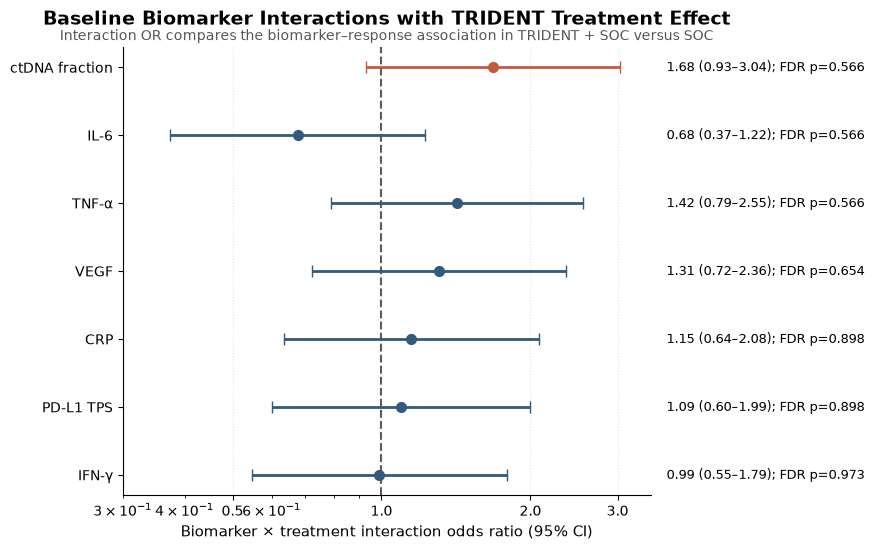

Figure saved to: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results/figures/treatment_specific_biomarker_interaction_forest_plot.png
Figure exists: True


In [58]:
# Objective: Create a portfolio-quality forest plot of interaction ORs

# Keep biomarkers ordered by raw interaction p-value,
# with the strongest statistical evidence at the top
interaction_plot_data = interaction_results_numeric.copy()

# Create vertical positions for the seven biomarkers
interaction_y_positions = np.arange(
    len(interaction_plot_data)
)

# Calculate asymmetric confidence-interval distances
interaction_xerr = np.vstack([
    interaction_plot_data["interaction_or"]
    - interaction_plot_data["interaction_ci_lower"],
    
    interaction_plot_data["interaction_ci_upper"]
    - interaction_plot_data["interaction_or"],
])

# Highlight ctDNA as hypothesis-generating, not significant
interaction_colors = [
    "#C45A3C" if biomarker == "ctDNA fraction" else "#315A7D"
    for biomarker in interaction_plot_data["biomarker"]
]

# Create the figure and plotting axis
interaction_forest_fig, interaction_forest_ax = plt.subplots(
    figsize=(11, 6.5)
)

# Plot each estimate separately so point colors can differ
for row_index, (_, row) in enumerate(
    interaction_plot_data.iterrows()
):
    interaction_forest_ax.errorbar(
        x=row["interaction_or"],
        y=interaction_y_positions[row_index],
        xerr=[
            [row["interaction_or"] - row["interaction_ci_lower"]],
            [row["interaction_ci_upper"] - row["interaction_or"]],
        ],
        fmt="o",
        color=interaction_colors[row_index],
        ecolor=interaction_colors[row_index],
        markersize=7,
        capsize=4,
        linewidth=2,
        zorder=3,
    )

    # Add the numeric interaction result to the right of the plot
    interaction_forest_ax.text(
        1.03,
        interaction_y_positions[row_index],
        (
            f"{row['interaction_or']:.2f} "
            f"({row['interaction_ci_lower']:.2f}–"
            f"{row['interaction_ci_upper']:.2f}); "
            f"FDR p={row['fdr_p_value']:.3f}"
        ),
        transform=interaction_forest_ax.get_yaxis_transform(),
        va="center",
        fontsize=9.5,
    )

# Add the null reference line
interaction_forest_ax.axvline(
    x=1,
    color="#555555",
    linestyle="--",
    linewidth=1.5,
    zorder=1,
)

# Use a logarithmic scale because odds ratios are multiplicative
interaction_forest_ax.set_xscale("log")
interaction_forest_ax.set_xlim(0.30, 3.50)
interaction_forest_ax.set_xticks([0.5, 1.0, 2.0, 3.0])
interaction_forest_ax.set_xticklabels(
    ["0.5", "1.0", "2.0", "3.0"]
)

# Add biomarker labels
interaction_forest_ax.set_yticks(interaction_y_positions)
interaction_forest_ax.set_yticklabels(
    interaction_plot_data["biomarker"]
)

# Place the smallest raw p-value at the top
interaction_forest_ax.invert_yaxis()

# Add clear scientific labels
interaction_forest_ax.set_xlabel(
    "Biomarker × treatment interaction odds ratio (95% CI)",
    fontsize=11,
)
interaction_forest_ax.set_ylabel("")
interaction_forest_ax.set_title(
    "Baseline Biomarker Interactions with TRIDENT Treatment Effect",
    fontsize=14,
    weight="bold",
    pad=16,
)

# Add a concise explanatory subtitle
interaction_forest_ax.text(
    0.5,
    1.015,
    (
        "Interaction OR compares the biomarker–response association "
        "in TRIDENT + SOC versus SOC"
    ),
    transform=interaction_forest_ax.transAxes,
    ha="center",
    fontsize=10,
    color="#555555",
)

# Use light horizontal grid lines without visual clutter
interaction_forest_ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.35,
)
sns.despine(
    ax=interaction_forest_ax,
    top=True,
    right=True,
)

# Leave room on the right for numeric annotations
interaction_forest_fig.subplots_adjust(
    left=0.18,
    right=0.66,
    top=0.84,
    bottom=0.15,
)

# Define and save the figure path
interaction_forest_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "treatment_specific_biomarker_interaction_forest_plot.png"
)

interaction_forest_fig.savefig(
    interaction_forest_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm that the figure was saved
print("Figure saved to:", interaction_forest_path)
print("Figure exists:", interaction_forest_path.exists())

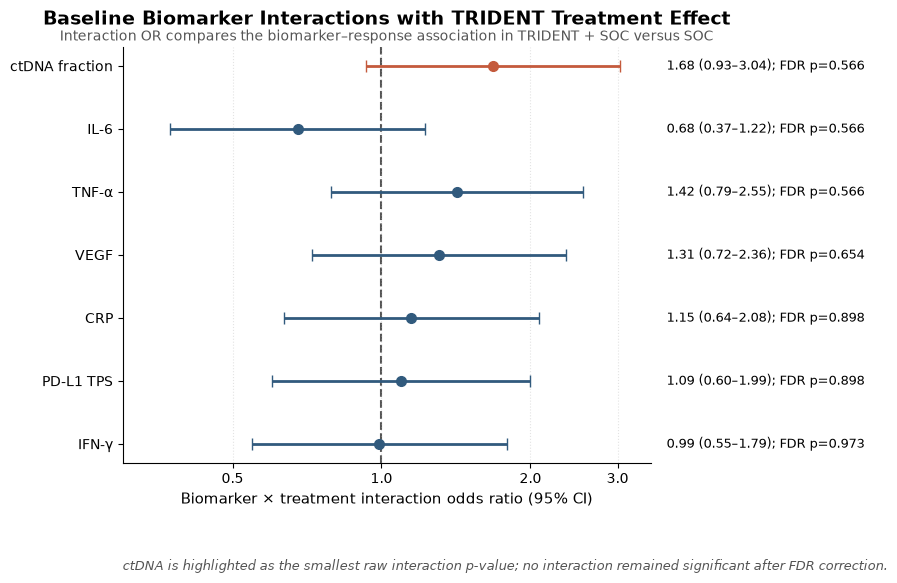

Polished figure saved to: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results/figures/treatment_specific_biomarker_interaction_forest_plot.png
Figure exists: True


In [59]:
# Objective: Refine the forest plot's x-axis and explanatory note

# Import fixed tick controls for the logarithmic x-axis
from matplotlib.ticker import (
    FixedLocator,
    FixedFormatter,
    NullLocator,
)

# Show only four reader-friendly major tick values
interaction_forest_ax.xaxis.set_major_locator(
    FixedLocator([0.5, 1.0, 2.0, 3.0])
)
interaction_forest_ax.xaxis.set_major_formatter(
    FixedFormatter(["0.5", "1.0", "2.0", "3.0"])
)

# Remove unlabeled minor ticks that make the axis look crowded
interaction_forest_ax.xaxis.set_minor_locator(
    NullLocator()
)

# Explain the ctDNA highlight without implying significance
interaction_forest_note = interaction_forest_fig.text(
    0.18,
    0.035,
    (
        "ctDNA is highlighted as the smallest raw interaction "
        "p-value; no interaction remained significant after FDR correction."
    ),
    ha="left",
    fontsize=9,
    color="#555555",
    style="italic",
)

# Leave room for the explanatory note
interaction_forest_fig.subplots_adjust(
    left=0.18,
    right=0.66,
    top=0.84,
    bottom=0.20,
)

# Overwrite the earlier version with the polished figure
interaction_forest_fig.savefig(
    interaction_forest_path,
    dpi=300,
    bbox_inches="tight",
)

# Redisplay and confirm the saved output
display(interaction_forest_fig)

print("Polished figure saved to:", interaction_forest_path)
print("Figure exists:", interaction_forest_path.exists())

In [60]:
# Objective: Create and save the ctDNA sensitivity-analysis comparison

# Combine the primary and sensitivity ctDNA results
ctdna_sensitivity_comparison = pd.DataFrame([
    {
        "analysis": "Primary: includes TRI-018",
        **ctdna_primary_extracted_result,
    },
    {
        "analysis": "Sensitivity: excludes TRI-018",
        **ctdna_sensitivity_extracted_result,
    },
])

# Keep the fields needed to evaluate robustness
ctdna_sensitivity_comparison = ctdna_sensitivity_comparison[
    [
        "analysis",
        "model_n",
        "model_scale_sd",
        "soc_biomarker_or_per_sd",
        "trident_biomarker_or_per_sd",
        "interaction_or",
        "interaction_ci_lower",
        "interaction_ci_upper",
        "interaction_p_value",
        "converged",
    ]
]

# Define and save the comparison table
ctdna_sensitivity_path = (
    interaction_table_dir
    / "ctdna_interaction_sensitivity_analysis.csv"
)

ctdna_sensitivity_comparison.to_csv(
    ctdna_sensitivity_path,
    index=False,
)

# Confirm and display the saved results
print("Saved to:", ctdna_sensitivity_path)
print("Table shape:", ctdna_sensitivity_comparison.shape)
print("File exists:", ctdna_sensitivity_path.exists())

ctdna_sensitivity_comparison.round(3)

Saved to: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results/tables/ctdna_interaction_sensitivity_analysis.csv
Table shape: (2, 10)
File exists: True


,analysis,model_n,model_scale_sd,soc_biomarker_or_per_sd,trident_biomarker_or_per_sd,interaction_or,interaction_ci_lower,interaction_ci_upper,interaction_p_value,converged
0,Primary: includes TRI-018,246,0.878,0.782,1.316,1.682,0.931,3.036,0.085,True
1,Sensitivity: excludes TRI-018,245,0.854,0.802,1.306,1.627,0.907,2.921,0.103,True


## Overall conclusion: treatment-specific biomarker analysis

### Scientific question

Do baseline biomarkers have different associations with objective response in the TRIDENT + SOC and SOC treatment arms?

### Primary interaction findings

Seven baseline biomarkers were evaluated using logistic regression models containing treatment, standardized biomarker, and biomarker-by-treatment interaction terms. Biomarker transformations were selected before interaction testing based on data quality, distribution shape, and biological interpretability.

The largest interaction point estimate was observed for ctDNA fraction:

- SOC biomarker OR per SD: 0.782
- TRIDENT + SOC biomarker OR per SD: 1.316
- Interaction OR: 1.682
- 95% CI: 0.931–3.036
- Raw p-value: 0.085
- FDR-adjusted p-value: 0.566

This point estimate suggested that the relative TRIDENT + SOC treatment advantage may increase with higher baseline ctDNA. However, the confidence interval included 1, and the interaction was not statistically significant before or after multiple-testing correction.

IL-6 showed the strongest interaction estimate below 1:

- SOC biomarker OR per SD: 1.315
- TRIDENT + SOC biomarker OR per SD: 0.890
- Interaction OR: 0.677
- 95% CI: 0.374–1.225
- Raw p-value: 0.197
- FDR-adjusted p-value: 0.566

This suggested that the relative treatment advantage may decrease as baseline IL-6 increases, but the estimate was imprecise and did not provide convincing evidence of interaction.

The interaction estimates for TNF-α, VEGF, CRP, PD-L1 TPS, and IFN-γ were also uncertain, and all corresponding confidence intervals included 1.

### Multiple-testing conclusion

No biomarker-by-treatment interaction was statistically significant among the seven raw tests. After Benjamini–Hochberg correction, all FDR-adjusted p-values exceeded 0.05.

Therefore, none of the seven baseline biomarkers demonstrated statistically supported treatment-specific predictive value for objective response in this dataset.

### ctDNA sensitivity analysis

The primary ctDNA analysis retained TRI-018's extreme but biologically possible baseline ctDNA fraction of 95%. Excluding this patient produced a similar interaction estimate:

- Primary interaction OR: 1.682 (95% CI: 0.931–3.036; p = 0.085)
- Sensitivity interaction OR: 1.627 (95% CI: 0.907–2.921; p = 0.103)

The direction and approximate magnitude of the ctDNA interaction were reasonably robust to excluding this observation. Nevertheless, the evidence remained insufficient to establish ctDNA as a predictive biomarker.

### Pharmaceutical interpretation

TRIDENT + SOC improved objective response in the overall analysis population, but the current interaction analyses did not identify a baseline biomarker that reliably distinguished patients with greater relative treatment benefit.

ctDNA may warrant further hypothesis-driven evaluation because it produced the largest interaction estimate, the smallest raw interaction p-value, and a similar estimate in sensitivity analysis. Any further development would require confirmation in a larger independent dataset, prespecified analysis, evaluation of clinically meaningful cut points, and assessment alongside relevant clinical covariates.

These results should not currently be used to select treatment or exclude patients from TRIDENT + SOC.

In [61]:
# Objective: Verify all final Notebook 05 output files

# Define the portfolio-quality outputs created in Notebook 05
notebook_05_output_paths = {
    "PD-L1 predicted-probability figure": (
        PROJECT_ROOT
        / "results"
        / "figures"
        / "pdl1_treatment_interaction_predicted_probabilities.png"
    ),
    "Interaction forest plot": interaction_forest_path,
    "Numeric interaction results": interaction_numeric_path,
    "Formatted interaction results": interaction_formatted_path,
    "ctDNA sensitivity results": ctdna_sensitivity_path,
}

# Create one verification row per expected output
notebook_05_output_check = pd.DataFrame([
    {
        "output": output_name,
        "path": str(output_path),
        "exists": output_path.exists(),
        "size_kb": (
            round(output_path.stat().st_size / 1024, 1)
            if output_path.exists()
            else np.nan
        ),
    }
    for output_name, output_path
    in notebook_05_output_paths.items()
])

# Display the complete verification table
notebook_05_output_check

,output,path,exists,size_kb
0,PD-L1 predicted-probability figure,/Users/goncabulbul/Documents/GitHub/TRIDENT-20...,True,253.2
1,Interaction forest plot,/Users/goncabulbul/Documents/GitHub/TRIDENT-20...,True,193.3
2,Numeric interaction results,/Users/goncabulbul/Documents/GitHub/TRIDENT-20...,True,1.6
3,Formatted interaction results,/Users/goncabulbul/Documents/GitHub/TRIDENT-20...,True,0.8
4,ctDNA sensitivity results,/Users/goncabulbul/Documents/GitHub/TRIDENT-20...,True,0.5
